In [1]:
# Import the libraries required for AFL data inventory, exploration, and data-quality checks.
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)

# Task 1 — AFL Data Inventory & Understanding

## Dataset Inventory

The AFL data consists of four primary raw datasets. `afl_players_info_raw.csv` represents player-level information, with one record per player. `afl_players_round_by_round_stats_raw.csv` contains player performance records at the match/round level. `afl_players_seasonal_stats_raw.csv` contains player statistics aggregated at the player-season level. `team_matches_home_away_raw (1).csv` contains team-level match records representing the two team perspectives of a match.

## Grain and Join Structure

The player information table is at player grain and connects to player performance and seasonal statistics through `player_id`. The round-by-round statistics are at player-match/round grain, while seasonal statistics are at player-season grain. The team match dataset is at team-match grain, with two records representing the two teams involved in a match. Because a direct reliable match identifier is not available consistently across the source tables, a canonical `match_key` is constructed from the match date and the alphabetically ordered pair of participating teams.

The canonical match key allows player-match records to be connected to the team-level match information while preventing the home/away representation from creating two different identifiers for the same match.

## Temporal Coverage

The datasets were examined for date ranges, seasons, teams, and players. The exact coverage is reported in the generated `date_ranges`, `season_summary`, `team_counts`, and `player_counts` tables. Team appearance by season was also examined to identify teams entering or leaving the observed dataset period.

## Data Quality

Data quality was evaluated through missing-value analysis, duplicate detection, naming-consistency checks, and statistical outlier detection. Missing values were quantified by column and dataset rather than automatically removed because missingness can have different meanings for different AFL statistics.

Duplicate rows and duplicate identifiers were investigated separately because repeated identifiers can be legitimate at a higher-level grain. Team and player naming consistency was also checked, with stable identifiers such as `player_id` preferred over player names whenever available.

## Statistical Outliers

Key AFL performance variables such as goals, disposals, kicks, handballs, marks, tackles, and scoring statistics were examined using descriptive statistics and IQR-based outlier detection. Outliers were flagged for investigation rather than automatically removed because extreme AFL performances can represent genuine player performances rather than data errors.

## Structural Changes

Team presence across seasons was examined to identify teams that appear or disappear during the observed period. These changes may represent genuine AFL expansion, contraction, relocation, renaming, or differences in dataset coverage and should therefore be considered when creating historical and predictive features.

## Task 1 Conclusion

The AFL source data has been inventoried, its table grains and relationships have been investigated, temporal and entity coverage has been identified, and major data-quality risks have been assessed. The validated `player_id` and canonical `match_key` provide the main entity-level connections required for subsequent target definition and feature engineering. 

In [2]:
# Define the AFL dataset directory relative to the Week-6/day1 notebook location.
DATA_DIR = Path("./dataset")
print("Dataset directory:", DATA_DIR.resolve())

Dataset directory: D:\Netixsol_Intern_Projects\Week-6\day1\dataset


In [3]:
# Discover every CSV file available inside the AFL dataset directory.
csv_files = sorted(DATA_DIR.glob("*.csv"))
print(f"Total CSV files found: {len(csv_files)}")
for file in csv_files:
    print(file.name)

Total CSV files found: 18
afl_players_info_raw.csv
afl_players_round_by_round_stats_raw.csv
afl_players_seasonal_stats_raw.csv
context_summary.csv
declined_players.csv
enriched_round_stats.csv
final_analysis_dataset.csv
final_enriched_dataset.csv
home_vs_away.csv
improved_players.csv
merged_analysis_dataset.csv
most_consistent_players.csv
recommended_players.csv
team_matches_home_away_raw (1).csv
team_ranking.csv
top10_players.csv
unmatched_records.csv
venue_performance.csv


In [4]:
# Create an inventory showing each AFL file, its size, and whether it appears to be raw or derived.
file_inventory = pd.DataFrame({
    "file_name": [file.name for file in csv_files],
    "size_mb": [round(file.stat().st_size / (1024 ** 2), 2) for file in csv_files],
    "type": [
        "raw_source" if "_raw" in file.stem else "derived_analysis"
        for file in csv_files
    ],
    "path": [str(file.resolve()) for file in csv_files]
})

file_inventory.sort_values(
    ["type", "file_name"]
).reset_index(drop=True)

,file_name,size_mb,type,path
0,context_summary.csv,0.01,derived_analysis,D:\Netixsol_Intern_Projects\Week-6\day1\dataset\context_summary.csv
1,declined_players.csv,0.00,derived_analysis,D:\Netixsol_Intern_Projects\Week-6\day1\dataset\declined_players.csv
2,enriched_round_stats.csv,54.93,derived_analysis,D:\Netixsol_Intern_Projects\Week-6\day1\dataset\enriched_round_stats.csv
3,final_analysis_dataset.csv,4.81,derived_analysis,D:\Netixsol_Intern_Projects\Week-6\day1\dataset\final_analysis_dataset.csv
4,final_enriched_dataset.csv,54.93,derived_analysis,D:\Netixsol_Intern_Projects\Week-6\day1\dataset\final_enriched_dataset.csv
5,home_vs_away.csv,0.00,derived_analysis,D:\Netixsol_Intern_Projects\Week-6\day1\dataset\home_vs_away.csv
6,improved_players.csv,0.00,derived_analysis,D:\Netixsol_Intern_Projects\Week-6\day1\dataset\improved_players.csv
7,merged_analysis_dataset.csv,4.81,derived_analysis,D:\Netixsol_Intern_Projects\Week-6\day1\dataset\merged_analysis_dataset.csv
8,most_consistent_players.csv,0.00,derived_analysis,D:\Netixsol_Intern_Projects\Week-6\day1\dataset\most_consistent_players.csv
9,recommended_players.csv,0.00,derived_analysis,D:\Netixsol_Intern_Projects\Week-6\day1\dataset\recommended_players.csv


In [5]:
# Separate the original AFL source files from previously generated analysis and enrichment files.

raw_files = [
    file for file in csv_files
    if "_raw" in file.stem
]

derived_files = [
    file for file in csv_files
    if "_raw" not in file.stem
]

print("RAW SOURCE FILES")
print("-" * 50)

for file in raw_files:
    print(file.name)

print("\nDERIVED / ANALYSIS FILES")
print("-" * 50)

for file in derived_files:
    print(file.name)

RAW SOURCE FILES
--------------------------------------------------
afl_players_info_raw.csv
afl_players_round_by_round_stats_raw.csv
afl_players_seasonal_stats_raw.csv
team_matches_home_away_raw (1).csv

DERIVED / ANALYSIS FILES
--------------------------------------------------
context_summary.csv
declined_players.csv
enriched_round_stats.csv
final_analysis_dataset.csv
final_enriched_dataset.csv
home_vs_away.csv
improved_players.csv
merged_analysis_dataset.csv
most_consistent_players.csv
recommended_players.csv
team_ranking.csv
top10_players.csv
unmatched_records.csv
venue_performance.csv


In [6]:
# Load every raw AFL dataset into a dictionary so each source table can be analyzed independently.

raw_datasets = {}

for file in raw_files:
    try:
        raw_datasets[file.stem] = pd.read_csv(
            file,
            low_memory=False
        )

        print(
            f"{file.name:<55} "
            f"Rows: {len(raw_datasets[file.stem]):>8,} | "
            f"Columns: {len(raw_datasets[file.stem].columns):>3}"
        )

    except Exception as e:
        print(f"ERROR loading {file.name}: {e}")

afl_players_info_raw.csv                                Rows:    2,848 | Columns:  16
afl_players_round_by_round_stats_raw.csv                Rows:  274,089 | Columns:  36
afl_players_seasonal_stats_raw.csv                      Rows:   25,491 | Columns:  54
team_matches_home_away_raw (1).csv                      Rows:   15,808 | Columns:  19


In [7]:
# Summarize the number of rows and columns contained in every raw AFL dataset.
raw_shapes = pd.DataFrame([
    {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1]
    }
    for name, df in raw_datasets.items()
])

raw_shapes

,dataset,rows,columns
0,afl_players_info_raw,2848,16
1,afl_players_round_by_round_stats_raw,274089,36
2,afl_players_seasonal_stats_raw,25491,54
3,team_matches_home_away_raw (1),15808,19


In [8]:
# Display every column in each raw dataset to understand its available information and potential join keys.
for name, df in raw_datasets.items():
    print("\n" + "=" * 90)
    print(f"DATASET: {name}")
    print("=" * 90)

    for i, column in enumerate(df.columns, start=1):
        print(f"{i:>3}. {column}")


DATASET: afl_players_info_raw
  1. id
  2. player_name
  3. player_full_name
  4. first_name
  5. last_name
  6. born_date
  7. debut_date
  8. debut_age
  9. last_date
 10. last_age
 11. height
 12. weight
 13. profile_pic
 14. player_link
 15. player_common_names
 16. player_teams

DATASET: afl_players_round_by_round_stats_raw
  1. id
  2. team
  3. year
  4. career_game_count
  5. opponent
  6. round
  7. result
  8. jersey_num
  9. kicks
 10. marks
 11. handballs
 12. disposals
 13. goals
 14. behinds
 15. hit_outs
 16. tackles
 17. rebound_50s
 18. inside_50s
 19. clearances
 20. clangers
 21. free_kicks_for
 22. free_kicks_against
 23. brownlow_votes
 24. contested_possessions
 25. uncontested_possessions
 26. contested_marks
 27. marks_inside_50
 28. one_percenters
 29. bounces
 30. goal_assist
 31. percentage_of_game_played
 32. player_id
 33. match_date
 34. fantasy_points
 35. score
 36. margin

DATASET: afl_players_seasonal_stats_raw
  1. player_id
  2. year
  3. team
  4. 

In [9]:
# Display sample rows from every raw AFL dataset so we can determine what one row represents.

for name, df in raw_datasets.items():
    print("\n" + "=" * 90)
    print(f"DATASET: {name}")
    print("=" * 90)

    display(df.head(5))


DATASET: afl_players_info_raw


,id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,NaN,https://afltables.com/afl/stats/players/R/Ryan_Abbott.html,NaN,"{Geelong Cats,St Kilda Saints}"
1,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87,NaN,https://afltables.com/afl/stats/players/G/Gary_Ablett1.html,NaN,"{Geelong Cats,Gold Coast Suns}"
2,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,195,85,https://res.cloudinary.com/dijzdikkh/image/upload/v1774442936/afl_player_images_v2/43276.webp,https://afltables.com/afl/stats/players/L/Leek_Aleer.html,NaN,NaN
3,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,195,95,NaN,https://afltables.com/afl/stats/players/N/Nathan_Ablett.html,NaN,"{Geelong Cats,Gold Coast Suns}"
4,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,196,101,NaN,https://afltables.com/afl/stats/players/C/Cain_Ackland.html,NaN,"{Carlton Blues,Port Adelaide Power,St Kilda Saints}"



DATASET: afl_players_round_by_round_stats_raw


,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,handballs,disposals,goals,behinds,hit_outs,tackles,rebound_50s,inside_50s,clearances,clangers,free_kicks_for,free_kicks_against,brownlow_votes,contested_possessions,uncontested_possessions,contested_marks,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,2.0,2.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,3.0,1.0,NaN,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,5.0,14.0,NaN,NaN,NaN,NaN,4.0,3.0,5.0,1.0,NaN,NaN,NaN,10.0,7.0,1.0,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,8.0,15.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,4.0,3.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25



DATASET: afl_players_seasonal_stats_raw


,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,behinds,hit_outs,tackles,rebound_50s,inside_50s,clearances,clangers,free_kicks_for,free_kicks_against,brownlow_votes,contested_possessions,uncontested_possessions,contested_marks,marks_inside_50,one_percenters,bounces,goal_assists,total_score,total_fantasy_points,total_percentage_played,avg_kicks,avg_marks,avg_handballs,avg_disposals,avg_goals,avg_behinds,avg_hit_outs,avg_tackles,avg_rebound_50s,avg_inside_50s,avg_clearances,avg_clangers,avg_free_kicks_for,avg_free_kicks_against,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,2.0,82.0,18.0,2.0,2.0,8.0,10.0,2.0,6.0,0.0,20.0,20.0,1.0,5.0,13.0,0.0,1.0,20,278,253.0,5.7,3.0,7.0,12.7,1.0,0.7,27.3,6.0,0.7,0.7,2.7,3.3,0.7,2.0,6.7,6.7,0.3,1.7,4.3,0.0,0.3,6.7,92.7,84.3
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,1.0,27.0,5.0,0.0,0.0,0.0,3.0,0.0,2.0,0.0,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1,61,81.0,3.0,2.0,2.0,5.0,0.0,1.0,27.0,5.0,0.0,0.0,0.0,3.0,0.0,2.0,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1.0,61.0,81.0
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,0.0,24.0,4.0,1.0,2.0,3.0,4.0,1.0,3.0,0.0,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6,74,83.0,5.0,3.0,6.0,11.0,1.0,0.0,24.0,4.0,1.0,2.0,3.0,4.0,1.0,3.0,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6.0,74.0,83.0
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6,22,54.0,2.0,2.0,1.0,3.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6.0,22.0,54.0
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,3.0,0.0,25.0,1.0,17.0,13.0,11.0,7.0,1.0,0.0,68.0,36.0,3.0,3.0,12.0,2.0,0.0,63,443,NaN,3.1,1.1,5.3,8.3,0.8,0.3,0.0,2.1,0.1,1.4,1.1,0.9,0.6,0.1,5.7,3.0,0.3,0.3,1.0,0.2,0.0,5.3,36.9,NaN



DATASET: team_matches_home_away_raw (1)


,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
0,15807,Hawthorn Hawks,QF,1994-09-10,1994,A,North Melbourne Kangaroos,4.5 5.7 10.11 13.13 13.13 13.13,91,2.3 6.12 9.12 12.19 13.23 15.24,114,L,23,Waverley Park,38223.0,13,13,15,24
1,15808,North Melbourne Kangaroos,QF,1994-09-10,1994,H,Hawthorn Hawks,2.3 6.12 9.12 12.19 13.23 15.24,114,4.5 5.7 10.11 13.13 13.13 13.13,91,W,6,Waverley Park,38223.0,15,24,13,13
2,5646,North Melbourne Kangaroos,10,2008-05-31,2008,A,Brisbane Lions,2.2 6.2 12.3 15.8,98,4.7 11.12 15.17 18.21,129,L,-31,The Gabba,22118.0,15,8,18,21
3,8829,Sydney Swans,15,2017-06-30,2017,A,Melbourne Demons,1.8 5.15 8.16 11.19,85,4.0 4.1 5.4 7.8,50,W,35,Melbourne Cricket Ground,47464.0,11,19,7,8
4,8873,Sydney Swans,11,2019-06-01,2019,A,Geelong Cats,3.3 5.8 6.12 8.15,63,5.1 7.2 11.4 13.7,85,L,-22,GMHBA Stadium,29021.0,8,15,13,7


In [55]:
# Check duplicated record IDs without modifying the raw source dataset.

round_by_round_df = raw_datasets["afl_players_round_by_round_stats_raw"]

duplicate_id_rows = round_by_round_df[
    round_by_round_df.duplicated(
        subset=["id"],
        keep=False
    )
].sort_values("id")

print(f"Rows involved in duplicated IDs: {len(duplicate_id_rows):,}")
print(f"Duplicated ID values: {duplicate_id_rows['id'].nunique():,}")

display(duplicate_id_rows)

Rows involved in duplicated IDs: 0
Duplicated ID values: 0


,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,handballs,disposals,goals,behinds,hit_outs,tackles,rebound_50s,inside_50s,clearances,clangers,free_kicks_for,free_kicks_against,brownlow_votes,contested_possessions,uncontested_possessions,contested_marks,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin


In [54]:
# Infer the grain of every raw dataset by testing whether combinations of id-like columns uniquely identify each row.

from itertools import combinations

grain_report = []

for name, df in raw_datasets.items():

    candidate_grain_columns = [
        column
        for column in df.columns
        if any(keyword in column.lower() for keyword in [
            "id", "player", "team", "match", "season", "round"
        ])
    ]

    max_combo_size = min(4, len(candidate_grain_columns))
    grain_columns_used = []
    is_unique = False

    for r in range(1, max_combo_size + 1):
        for combo in combinations(candidate_grain_columns, r):
            if df.duplicated(subset=list(combo)).sum() == 0:
                grain_columns_used = list(combo)
                is_unique = True
                break
        if is_unique:
            break

    grain_report.append({
        "dataset": name,
        "rows": len(df),
        "inferred_grain_columns": grain_columns_used if grain_columns_used else "no unique combo found (checked up to 4 columns)",
        "grain_is_unique": is_unique
    })

grain_report = pd.DataFrame(grain_report)

grain_report

,dataset,rows,inferred_grain_columns,grain_is_unique
0,afl_players_info_raw,2848,no unique combo found (checked up to 4 columns),False
1,afl_players_round_by_round_stats_raw,274079,[id],True
2,afl_players_seasonal_stats_raw,25491,no unique combo found (checked up to 4 columns),False
3,team_matches_home_away_raw (1),15808,[id],True


In [56]:
# Create the human-readable grain definitions required for the final Task 1 documentation.

grain_documentation = pd.DataFrame([
    {
        "dataset": "afl_players_info_raw",
        "row_represents": "One AFL player",
        "grain": "player-level",
        "primary_entity": "player",
        "expected_join_keys": "player_id"
    },
    {
        "dataset": "afl_players_round_by_round_stats_raw",
        "row_represents": "One player performance record for a specific match/round",
        "grain": "player-match/round-level",
        "primary_entity": "player × match",
        "expected_join_keys": "player_id + match_key + season/round"
    },
    {
        "dataset": "afl_players_seasonal_stats_raw",
        "row_represents": "One player's statistics aggregated for a season",
        "grain": "player-season-level",
        "primary_entity": "player × season",
        "expected_join_keys": "player_id + season"
    },
    {
        "dataset": "team_matches_home_away_raw (1)",
        "row_represents": "One team perspective of a match",
        "grain": "team-match-level",
        "primary_entity": "team × match",
        "expected_join_keys": "match_key + team"
    }
])

display(grain_documentation)

,dataset,row_represents,grain,primary_entity,expected_join_keys
0,afl_players_info_raw,One AFL player,player-level,player,player_id
1,afl_players_round_by_round_stats_raw,One player performance record for a specific match/round,player-match/round-level,player × match,player_id + match_key + season/round
2,afl_players_seasonal_stats_raw,One player's statistics aggregated for a season,player-season-level,player × season,player_id + season
3,team_matches_home_away_raw (1),One team perspective of a match,team-match-level,team × match,match_key + team


In [10]:
# Identify common ID and time columns that help determine the grain and relationships between AFL tables.

id_columns = [
    column
    for df in raw_datasets.values()
    for column in df.columns
    if any(keyword in column.lower() for keyword in [
        "id", "player", "team", "match", "season", "round"
    ])
]

sorted(set(id_columns))

['avg_inside_50s',
 'avg_marks_inside_50',
 'id',
 'inside_50s',
 'marks_inside_50',
 'match_date',
 'player_common_names',
 'player_full_name',
 'player_id',
 'player_link',
 'player_name',
 'player_teams',
 'round',
 'team',
 'team_behinds',
 'team_goals_kicked',
 'team_name',
 'team_quarter_scores',
 'team_score']

In [11]:
# Compare row counts and unique identifier counts to help determine the grain of every raw dataset.
for name, df in raw_datasets.items():
    print("\n" + "=" * 90)
    print(f"DATASET: {name}")
    print(f"Rows: {len(df):,}")
    print("=" * 90)

    for column in df.columns:
        if any(keyword in column.lower() for keyword in [
            "id", "player", "team", "match", "season", "round"
        ]):
            print(
                f"{column:<30} "
                f"Unique: {df[column].nunique(dropna=True):>8,}"
            )


DATASET: afl_players_info_raw
Rows: 2,848
id                             Unique:    2,843
player_name                    Unique:    2,826
player_full_name               Unique:    2,843
player_link                    Unique:    2,843
player_common_names            Unique:       75
player_teams                   Unique:      309

DATASET: afl_players_round_by_round_stats_raw
Rows: 274,089
id                             Unique:  274,079
team                           Unique:       20
round                          Unique:       30
inside_50s                     Unique:       17
marks_inside_50                Unique:       15
player_id                      Unique:    3,109
match_date                     Unique:    3,276

DATASET: afl_players_seasonal_stats_raw
Rows: 25,491
player_id                      Unique:    3,117
team                           Unique:      114
inside_50s                     Unique:      150
marks_inside_50                Unique:      105
avg_inside_50s            

In [12]:
# Create a detailed schema inventory containing data types, missing values, and unique-value counts for every raw column.
schema_inventory = []
for name, df in raw_datasets.items():
    for column in df.columns:
        schema_inventory.append({
            "dataset": name,
            "column": column,
            "dtype": str(df[column].dtype),
            "rows": len(df),
            "unique_values": df[column].nunique(dropna=True),
            "missing_count": df[column].isna().sum(),
            "missing_percent": round(
                df[column].isna().mean() * 100,
                2
            )
        })

schema_inventory = pd.DataFrame(schema_inventory)

schema_inventory

,dataset,column,dtype,rows,unique_values,missing_count,missing_percent
0,afl_players_info_raw,id,int64,2848,2843,0,0.00
1,afl_players_info_raw,player_name,str,2848,2826,0,0.00
2,afl_players_info_raw,player_full_name,str,2848,2843,0,0.00
3,afl_players_info_raw,first_name,str,2848,742,0,0.00
4,afl_players_info_raw,last_name,str,2848,1998,0,0.00
...,...,...,...,...,...,...,...
120,team_matches_home_away_raw (1),crowd,float64,15808,7147,398,2.52
121,team_matches_home_away_raw (1),team_goals_kicked,int64,15808,37,0,0.00
122,team_matches_home_away_raw (1),team_behinds,int64,15808,31,0,0.00
123,team_matches_home_away_raw (1),opponent_goals_kicked,int64,15808,37,0,0.00


In [13]:
# Identify columns whose names suggest they contain dates or timestamps in the raw AFL datasets.

possible_date_columns = {}

for name, df in raw_datasets.items():
    possible_date_columns[name] = [
        column
        for column in df.columns
        if any(keyword in column.lower() for keyword in [
            "date", "datetime", "timestamp"
        ])
    ]

possible_date_columns

{'afl_players_info_raw': ['born_date', 'debut_date', 'last_date'],
 'afl_players_round_by_round_stats_raw': ['match_date'],
 'afl_players_seasonal_stats_raw': [],
 'team_matches_home_away_raw (1)': ['match_date']}

In [40]:
# Convert detected date columns to pandas datetime format and record how many values failed to parse.

date_parse_report = []

for name, columns in possible_date_columns.items():
    for column in columns:

        original_non_null = raw_datasets[name][column].notna().sum()

        raw_datasets[name][column] = pd.to_datetime(
            raw_datasets[name][column],
            errors="coerce"
        )

        parsed_non_null = raw_datasets[name][column].notna().sum()
        failed_to_parse = original_non_null - parsed_non_null

        date_parse_report.append({
            "dataset": name,
            "column": column,
            "original_non_null": int(original_non_null),
            "parsed_non_null": int(parsed_non_null),
            "failed_to_parse": int(failed_to_parse)
        })

date_parse_report = pd.DataFrame(date_parse_report)

date_parse_report

,dataset,column,original_non_null,parsed_non_null,failed_to_parse
0,afl_players_info_raw,born_date,2848,2848,0
1,afl_players_info_raw,debut_date,2848,2848,0
2,afl_players_info_raw,last_date,2848,2848,0
3,afl_players_round_by_round_stats_raw,match_date,274089,274089,0
4,team_matches_home_away_raw (1),match_date,15808,15808,0


In [15]:
# Calculate the earliest and latest dates available in every raw AFL dataset.

date_ranges = []

for name, columns in possible_date_columns.items():
    for column in columns:

        valid_dates = raw_datasets[name][column].dropna()

        if len(valid_dates) > 0:
            date_ranges.append({
                "dataset": name,
                "date_column": column,
                "start_date": valid_dates.min(),
                "end_date": valid_dates.max(),
                "unique_dates": valid_dates.nunique()
            })

date_ranges = pd.DataFrame(date_ranges)

date_ranges

,dataset,date_column,start_date,end_date,unique_dates
0,afl_players_info_raw,born_date,1963-10-23,2006-12-24,2546
1,afl_players_info_raw,debut_date,1983-03-27,2025-08-22,1610
2,afl_players_info_raw,last_date,1999-03-27,2026-03-07,1305
3,afl_players_round_by_round_stats_raw,match_date,1983-03-27,2025-09-27,3276
4,team_matches_home_away_raw (1),match_date,1983-03-26,2025-09-27,3347


In [16]:
# Identify season and year columns that can be used to determine the historical AFL coverage.
season_columns = {}
for name, df in raw_datasets.items():
    season_columns[name] = [
        column
        for column in df.columns
        if "season" in column.lower() or column.lower() == "year"
    ]

season_columns

{'afl_players_info_raw': [],
 'afl_players_round_by_round_stats_raw': ['year'],
 'afl_players_seasonal_stats_raw': ['year'],
 'team_matches_home_away_raw (1)': ['year']}

In [17]:
# Display the minimum season, maximum season, and number of seasons available in every raw dataset.

season_summary = []

for name, columns in season_columns.items():
    for column in columns:

        values = pd.to_numeric(
            raw_datasets[name][column],
            errors="coerce"
        ).dropna()

        if len(values) > 0:
            season_summary.append({
                "dataset": name,
                "season_column": column,
                "first_season": int(values.min()),
                "last_season": int(values.max()),
                "number_of_seasons": values.nunique()
            })

season_summary = pd.DataFrame(season_summary)

season_summary

,dataset,season_column,first_season,last_season,number_of_seasons
0,afl_players_round_by_round_stats_raw,year,1983,2025,43
1,afl_players_seasonal_stats_raw,year,1983,2025,43
2,team_matches_home_away_raw (1),year,1983,2025,43


In [18]:
# Identify player ID and player-name columns across the raw AFL datasets.

for name, df in raw_datasets.items():

    player_columns = [
        column
        for column in df.columns
        if "player" in column.lower()
    ]

    if player_columns:
        print(f"\n{name}")
        print(player_columns)


afl_players_info_raw
['player_name', 'player_full_name', 'player_link', 'player_common_names', 'player_teams']

afl_players_round_by_round_stats_raw
['player_id']

afl_players_seasonal_stats_raw
['player_id']


In [19]:
# Count the number of unique players represented in each raw AFL dataset.

player_counts = []

for name, df in raw_datasets.items():

    player_columns = [
        column
        for column in df.columns
        if "player" in column.lower()
    ]

    for column in player_columns:

        player_counts.append({
            "dataset": name,
            "column": column,
            "unique_players": df[column].nunique(dropna=True)
        })

player_counts = pd.DataFrame(player_counts)

player_counts

,dataset,column,unique_players
0,afl_players_info_raw,player_name,2826
1,afl_players_info_raw,player_full_name,2843
2,afl_players_info_raw,player_link,2843
3,afl_players_info_raw,player_common_names,75
4,afl_players_info_raw,player_teams,309
5,afl_players_round_by_round_stats_raw,player_id,3109
6,afl_players_seasonal_stats_raw,player_id,3117


In [63]:
# Validate that each player_id maps consistently to a single player name.

player_identity_report = []

for name, df in raw_datasets.items():

    player_id_columns = [
        column for column in df.columns
        if column.lower() == "player_id"
    ]

    player_name_columns = [
        column for column in df.columns
        if "player" in column.lower()
        and "id" not in column.lower()
    ]

    if player_id_columns and player_name_columns:

        player_id_col = player_id_columns[0]
        player_name_col = player_name_columns[0]

        identity_check = (
            df.dropna(subset=[player_id_col, player_name_col])
            .groupby(player_id_col)[player_name_col]
            .nunique()
        )

        inconsistent = identity_check[identity_check > 1]

        player_identity_report.append({
            "dataset": name,
            "player_id_column": player_id_col,
            "player_name_column": player_name_col,
            "player_ids_checked": len(identity_check),
            "inconsistent_player_ids": len(inconsistent)
        })

player_identity_report = pd.DataFrame(player_identity_report)

display(player_identity_report)

""


In [20]:
# Identify team ID and team-name columns across the raw AFL datasets.

for name, df in raw_datasets.items():

    team_columns = [
        column
        for column in df.columns
        if "team" in column.lower()
    ]

    if team_columns:
        print(f"\n{name}")
        print(team_columns)


afl_players_info_raw
['player_teams']

afl_players_round_by_round_stats_raw
['team']

afl_players_seasonal_stats_raw
['team']

team_matches_home_away_raw (1)
['team_name', 'team_quarter_scores', 'team_score', 'team_goals_kicked', 'team_behinds']


In [21]:
# Count the unique team identifiers or team names represented in every raw AFL dataset.

team_counts = []

for name, df in raw_datasets.items():

    team_columns = [
        column
        for column in df.columns
        if "team" in column.lower()
    ]

    for column in team_columns:

        team_counts.append({
            "dataset": name,
            "column": column,
            "unique_teams": df[column].nunique(dropna=True)
        })

team_counts = pd.DataFrame(team_counts)

team_counts

,dataset,column,unique_teams
0,afl_players_info_raw,player_teams,309
1,afl_players_round_by_round_stats_raw,team,20
2,afl_players_seasonal_stats_raw,team,114
3,team_matches_home_away_raw (1),team_name,40
4,team_matches_home_away_raw (1),team_quarter_scores,15750
5,team_matches_home_away_raw (1),team_score,204
6,team_matches_home_away_raw (1),team_goals_kicked,37
7,team_matches_home_away_raw (1),team_behinds,31


In [22]:
# Find columns shared by multiple raw AFL datasets because shared identifiers are potential join keys.

column_usage = {}

for name, df in raw_datasets.items():
    for column in df.columns:
        column_usage.setdefault(column, []).append(name)

common_columns = {
    column: datasets
    for column, datasets in column_usage.items()
    if len(datasets) > 1
}

for column, datasets in common_columns.items():
    print(f"{column}: {datasets}")

id: ['afl_players_info_raw', 'afl_players_round_by_round_stats_raw', 'team_matches_home_away_raw (1)']
team: ['afl_players_round_by_round_stats_raw', 'afl_players_seasonal_stats_raw']
year: ['afl_players_round_by_round_stats_raw', 'afl_players_seasonal_stats_raw', 'team_matches_home_away_raw (1)']
opponent: ['afl_players_round_by_round_stats_raw', 'team_matches_home_away_raw (1)']
round: ['afl_players_round_by_round_stats_raw', 'team_matches_home_away_raw (1)']
result: ['afl_players_round_by_round_stats_raw', 'team_matches_home_away_raw (1)']
kicks: ['afl_players_round_by_round_stats_raw', 'afl_players_seasonal_stats_raw']
marks: ['afl_players_round_by_round_stats_raw', 'afl_players_seasonal_stats_raw']
handballs: ['afl_players_round_by_round_stats_raw', 'afl_players_seasonal_stats_raw']
disposals: ['afl_players_round_by_round_stats_raw', 'afl_players_seasonal_stats_raw']
goals: ['afl_players_round_by_round_stats_raw', 'afl_players_seasonal_stats_raw']
behinds: ['afl_players_round_by_r

In [43]:
# Create a matrix showing which raw datasets contain each important AFL join key.
# Uses canonical (alphanumeric-only, lowercased) matching so variants like Player_ID, PlayerId, "player id" are all detected.

def canonical(text):
    return "".join(character for character in text.lower() if character.isalnum())

join_keys = [
    "match_id",
    "player_id",
    "team_id",
    "season",
    "round"
]

join_key_canonical = {key: canonical(key) for key in join_keys}

join_matrix = pd.DataFrame(
    index=raw_datasets.keys(),
    columns=join_keys
)

for name, df in raw_datasets.items():
    canonical_columns = {canonical(column) for column in df.columns}
    for key in join_keys:
        join_matrix.loc[name, key] = join_key_canonical[key] in canonical_columns

join_matrix

,match_id,player_id,team_id,season,round
afl_players_info_raw,False,False,False,False,False
afl_players_round_by_round_stats_raw,False,True,False,False,True
afl_players_seasonal_stats_raw,False,True,False,False,False
team_matches_home_away_raw (1),False,False,False,False,True


In [44]:
# Summarize a plain-language join map: for each pair of datasets, list shared join-like columns.

dataset_names = list(raw_datasets.keys())
join_map_summary = []

for i in range(len(dataset_names)):
    for j in range(i + 1, len(dataset_names)):

        name_a = dataset_names[i]
        name_b = dataset_names[j]

        canonical_a = {canonical(column): column for column in raw_datasets[name_a].columns}
        canonical_b = {canonical(column): column for column in raw_datasets[name_b].columns}

        shared_canonical = set(canonical_a.keys()) & set(canonical_b.keys())
        shared_join_like = [
            canonical_a[key]
            for key in shared_canonical
            if key in join_key_canonical.values()
        ]

        if shared_join_like:
            join_map_summary.append({
                "dataset_a": name_a,
                "dataset_b": name_b,
                "shared_join_columns": shared_join_like
            })

join_map_summary = pd.DataFrame(join_map_summary)

join_map_summary

,dataset_a,dataset_b,shared_join_columns
0,afl_players_round_by_round_stats_raw,afl_players_seasonal_stats_raw,[player_id]
1,afl_players_round_by_round_stats_raw,team_matches_home_away_raw (1),[round]


In [25]:
# Calculate missing-value counts and percentages for every column in every raw AFL dataset.

missing_report = []

for name, df in raw_datasets.items():

    for column in df.columns:

        missing_count = df[column].isna().sum()

        missing_report.append({
            "dataset": name,
            "column": column,
            "missing_count": int(missing_count),
            "missing_percent": round(
                missing_count / len(df) * 100,
                2
            )
        })

missing_report = pd.DataFrame(missing_report)

missing_report = missing_report.sort_values(
    "missing_percent",
    ascending=False
)

missing_report
# Filter the missing-value report so only columns containing missing data are displayed.

missing_report[
    missing_report["missing_count"] > 0
]

,dataset,column,missing_count,missing_percent
50,afl_players_round_by_round_stats_raw,score,274089,100.00
14,afl_players_info_raw,player_common_names,2773,97.37
12,afl_players_info_raw,profile_pic,2211,77.63
38,afl_players_round_by_round_stats_raw,brownlow_votes,110481,40.31
45,afl_players_round_by_round_stats_raw,goal_assist,103600,37.80
44,afl_players_round_by_round_stats_raw,bounces,97343,35.52
30,afl_players_round_by_round_stats_raw,hit_outs,96629,35.25
42,afl_players_round_by_round_stats_raw,marks_inside_50,91378,33.34
41,afl_players_round_by_round_stats_raw,contested_marks,90677,33.08
29,afl_players_round_by_round_stats_raw,behinds,81093,29.59


In [26]:
# Check every raw AFL dataset for completely duplicated rows.

duplicate_report = []

for name, df in raw_datasets.items():

    duplicates = df.duplicated().sum()

    duplicate_report.append({
        "dataset": name,
        "total_rows": len(df),
        "duplicate_rows": int(duplicates),
        "duplicate_percent": round(
            duplicates / len(df) * 100,
            2
        )
    })

duplicate_report = pd.DataFrame(duplicate_report)

duplicate_report

,dataset,total_rows,duplicate_rows,duplicate_percent
0,afl_players_info_raw,2848,5,0.18
1,afl_players_round_by_round_stats_raw,274089,10,0.00
2,afl_players_seasonal_stats_raw,25491,10,0.04
3,team_matches_home_away_raw (1),15808,0,0.00


In [27]:
# Check the uniqueness of common identifiers so potential primary-key problems can be identified without assuming every ID must be unique.

candidate_keys = [
    "match_id",
    "player_id",
    "team_id"
]

for name, df in raw_datasets.items():

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    for key in candidate_keys:

        if key in df.columns:

            print(
                f"{key}: "
                f"{df[key].nunique(dropna=True):,} unique / "
                f"{len(df):,} rows"
            )


afl_players_info_raw

afl_players_round_by_round_stats_raw
player_id: 3,109 unique / 274,089 rows

afl_players_seasonal_stats_raw
player_id: 3,117 unique / 25,491 rows

team_matches_home_away_raw (1)


In [28]:
# Display all distinct team-name values so historical names, abbreviations, and spelling inconsistencies can be identified.

for name, df in raw_datasets.items():

    team_name_columns = [
        column
        for column in df.columns
        if "team" in column.lower()
        and "id" not in column.lower()
    ]

    for column in team_name_columns:

        print("\n" + "=" * 80)
        print(f"{name} -> {column}")
        print("=" * 80)

        display(
            pd.Series(
                sorted(
                    df[column]
                    .dropna()
                    .astype(str)
                    .unique()
                ),
                name=column
            ).to_frame()
        )


afl_players_info_raw -> player_teams


,player_teams
0,"{Adelaide Crows,Brisbane Bears,Brisbane Lions,St Kilda Saints}"
1,"{Adelaide Crows,Brisbane Lions,Collingwood Magpies,Western Bulldogs}"
2,"{Adelaide Crows,Brisbane Lions,Geelong Cats}"
3,"{Adelaide Crows,Brisbane Lions,Gold Coast Suns}"
4,"{Adelaide Crows,Brisbane Lions,Hawthorn Hawks}"
...,...
304,"{Sydney Swans,Western Bulldogs}"
305,{Sydney Swans}
306,"{West Coast Eagles,Western Bulldogs}"
307,{West Coast Eagles}



afl_players_round_by_round_stats_raw -> team


,team
0,Adelaide Crows
1,Brisbane Bears
2,Brisbane Lions
3,Carlton Blues
4,Collingwood Magpies
5,Essendon Bombers
6,Fitzroy Lions
7,Fremantle Dockers
8,Geelong Cats
9,Gold Coast Suns



afl_players_seasonal_stats_raw -> team


...

,team_score
0,100
1,101
2,102
3,103
4,104
...,...
199,95
200,96
201,97
202,98



team_matches_home_away_raw (1) -> team_goals_kicked


,team_goals_kicked
0,1
1,10
2,11
3,12
4,13
5,14
6,15
7,16
8,17
9,18



team_matches_home_away_raw (1) -> team_behinds


,team_behinds
0,1
1,10
2,11
3,12
4,13
5,14
6,15
7,16
8,17
9,18


In [45]:
# Compare team-name spellings across datasets to detect inconsistent naming (e.g. "Adelaide" vs "Adelaide Crows").

team_name_sets = {}

for name, df in raw_datasets.items():

    team_name_columns = [
        column
        for column in df.columns
        if "team" in column.lower()
        and "id" not in column.lower()
    ]

    if team_name_columns:
        column = team_name_columns[0]
        team_name_sets[name] = set(df[column].dropna().astype(str).unique())

dataset_names_with_teams = list(team_name_sets.keys())
naming_consistency_report = []

for i in range(len(dataset_names_with_teams)):
    for j in range(i + 1, len(dataset_names_with_teams)):

        name_a = dataset_names_with_teams[i]
        name_b = dataset_names_with_teams[j]

        only_in_a = team_name_sets[name_a] - team_name_sets[name_b]
        only_in_b = team_name_sets[name_b] - team_name_sets[name_a]

        naming_consistency_report.append({
            "dataset_a": name_a,
            "dataset_b": name_b,
            "names_only_in_a": sorted(only_in_a),
            "names_only_in_b": sorted(only_in_b)
        })

naming_consistency_report = pd.DataFrame(naming_consistency_report)

naming_consistency_report

,dataset_a,dataset_b,names_only_in_a,names_only_in_b
0,afl_players_info_raw,afl_players_round_by_round_stats_raw,"[{Adelaide Crows,Brisbane Bears,Brisbane Lions,St Kilda Saints}, {Adelaide Crows,Brisbane Lions,Collingwood Magpies,...","[Adelaide Crows, Brisbane Bears, Brisbane Lions, Carlton Blues, Collingwood Magpies, Essendon Bombers, Fitzroy Lions..."
1,afl_players_info_raw,afl_players_seasonal_stats_raw,"[{Adelaide Crows,Brisbane Bears,Brisbane Lions,St Kilda Saints}, {Adelaide Crows,Brisbane Lions,Collingwood Magpies,...","[ ADELAIDE CROWS , Adelaide Crows , BRISBANE LIONS , Brisbane Lions , CARLTON BLUES , COLLINGWOOD MAGPIES , Ca..."
2,afl_players_info_raw,team_matches_home_away_raw (1),"[{Adelaide Crows,Brisbane Bears,Brisbane Lions,St Kilda Saints}, {Adelaide Crows,Brisbane Lions,Collingwood Magpies,...","[\t Adelaide Crows , \tBrisbane Bears, \tBrisbane Lions, \tCarlton Blues, \tCollingwood Magpies, \tEssendon Bombers,..."
3,afl_players_round_by_round_stats_raw,afl_players_seasonal_stats_raw,[],"[ ADELAIDE CROWS , Adelaide Crows , BRISBANE LIONS , Brisbane Lions , CARLTON BLUES , COLLINGWOOD MAGPIES , Ca..."
4,afl_players_round_by_round_stats_raw,team_matches_home_away_raw (1),"[Adelaide Crows, Western Bulldogs]","[\t Adelaide Crows , \tBrisbane Bears, \tBrisbane Lions, \tCarlton Blues, \tCollingwood Magpies, \tEssendon Bombers,..."
5,afl_players_seasonal_stats_raw,team_matches_home_away_raw (1),"[ ADELAIDE CROWS , BRISBANE LIONS , Brisbane Lions , CARLTON BLUES , COLLINGWOOD MAGPIES , Carlton Blues , Col...","[\t Adelaide Crows , \tBrisbane Bears, \tBrisbane Lions, \tCarlton Blues, \tCollingwood Magpies, \tEssendon Bombers,..."


In [29]:
# Display the most frequent player names so spelling differences and inconsistent naming patterns can be investigated.

for name, df in raw_datasets.items():

    player_name_columns = [
        column
        for column in df.columns
        if "player" in column.lower()
        and "id" not in column.lower()
    ]

    for column in player_name_columns:

        print("\n" + "=" * 80)
        print(f"{name} -> {column}")
        print("=" * 80)

        display(
            df[column]
            .dropna()
            .astype(str)
            .value_counts()
            .head(30)
            .to_frame("count")
        )


afl_players_info_raw -> player_name


,count
player_name,
Ryan Abbott,2
Gary Ablett,2
Leek Aleer,2
Nathan Ablett,2
Cain Ackland,2
Aaron Black,2
Andrew Browne,2
Mitch Brown,2
Nathan Brown,2



afl_players_info_raw -> player_full_name


,count
player_full_name,
Ryan_Abbott,2
Gary_Ablett1,2
Leek_Aleer,2
Nathan_Ablett,2
Cain_Ackland,2
Blake_Acres,1
Leigh_Adams,1
Taylor_Adams,1
Jed_Adcock,1



afl_players_info_raw -> player_link


,count
player_link,
https://afltables.com/afl/stats/players/R/Ryan_Abbott.html,2
https://afltables.com/afl/stats/players/G/Gary_Ablett1.html,2
https://afltables.com/afl/stats/players/L/Leek_Aleer.html,2
https://afltables.com/afl/stats/players/N/Nathan_Ablett.html,2
https://afltables.com/afl/stats/players/C/Cain_Ackland.html,2
https://afltables.com/afl/stats/players/B/Blake_Acres.html,1
https://afltables.com/afl/stats/players/L/Leigh_Adams.html,1
https://afltables.com/afl/stats/players/T/Taylor_Adams.html,1
https://afltables.com/afl/stats/players/J/Jed_Adcock.html,1



afl_players_info_raw -> player_common_names


,count
player_common_names,
{Big Mac},1
{Andrews},1
{Tommy Atkins},1
{Bez},1
{The Lizard},1
{DBJ},1
{Chols Royce},1
{Cogs},1
{Crippa},1



afl_players_info_raw -> player_teams


,count
player_teams,
{Essendon Bombers},131
{West Coast Eagles},124
{Carlton Blues},116
{Richmond Tigers},114
{Collingwood Magpies},112
{Fremantle Dockers},111
{North Melbourne Kangaroos},107
{St Kilda Saints},104
{Melbourne Demons},104


In [30]:
# Calculate the number of unique teams appearing in each season to identify expansion, contraction, or historical structural changes.

for name, df in raw_datasets.items():

    if "season" not in df.columns:
        continue

    team_columns = [
        column
        for column in df.columns
        if "team" in column.lower()
        and "id" not in column.lower()
    ]

    if team_columns:

        team_column = team_columns[0]

        result = (
            df.groupby("season")[team_column]
            .nunique()
            .reset_index(name="unique_teams")
        )

        print("\n" + "=" * 80)
        print(name)
        print("=" * 80)

        display(result)

In [46]:
# Create a season-by-team matrix to identify when teams first and last appear and detect possible renames or structural changes.

season_team_crosstabs = {}

for name, df in raw_datasets.items():

    if "season" not in df.columns:
        continue

    team_columns = [
        column
        for column in df.columns
        if "team" in column.lower()
        and "id" not in column.lower()
    ]

    if team_columns:

        team_column = team_columns[0]

        season_team = pd.crosstab(
            df["season"],
            df[team_column]
        )

        season_team_crosstabs[name] = season_team

        print("\n" + "=" * 80)
        print(name)
        print("=" * 80)

        display(season_team)

In [50]:
# Flag teams whose first or last appearance falls inside the season range rather than at its edges — signals renames, relocations, expansion, or contraction.

structural_change_flags = []

for name, season_team in season_team_crosstabs.items():

    overall_first_season = season_team.index.min()
    overall_last_season = season_team.index.max()

    for team in season_team.columns:

        seasons_present = season_team.index[season_team[team] > 0]

        if len(seasons_present) == 0:
            continue

        team_first_season = seasons_present.min()
        team_last_season = seasons_present.max()

        starts_mid_range = team_first_season > overall_first_season
        ends_mid_range = team_last_season < overall_last_season

        if starts_mid_range or ends_mid_range:
            structural_change_flags.append({
                "dataset": name,
                "team": team,
                "first_season": team_first_season,
                "last_season": team_last_season,
                "starts_after_dataset_start": starts_mid_range,
                "ends_before_dataset_end": ends_mid_range
            })

structural_change_flags = pd.DataFrame(structural_change_flags)

structural_change_flags

""


In [32]:
# Identify numeric columns containing common AFL performance statistics for later outlier analysis.

stat_keywords = [
    "goal",
    "disposal",
    "kick",
    "handball",
    "mark",
    "tackle",
    "score",
    "point",
    "fantasy"
]

stat_columns = {}

for name, df in raw_datasets.items():

    columns = [
        column
        for column in df.columns
        if any(
            keyword in column.lower()
            for keyword in stat_keywords
        )
        and pd.api.types.is_numeric_dtype(df[column])
    ]

    stat_columns[name] = columns

    print(f"\n{name}")
    print(columns)


afl_players_info_raw
[]

afl_players_round_by_round_stats_raw
['kicks', 'marks', 'handballs', 'disposals', 'goals', 'tackles', 'free_kicks_for', 'free_kicks_against', 'contested_marks', 'marks_inside_50', 'goal_assist', 'fantasy_points', 'score']

afl_players_seasonal_stats_raw
['kicks', 'marks', 'handballs', 'disposals', 'goals', 'tackles', 'free_kicks_for', 'free_kicks_against', 'contested_marks', 'marks_inside_50', 'goal_assists', 'total_score', 'total_fantasy_points', 'avg_kicks', 'avg_marks', 'avg_handballs', 'avg_disposals', 'avg_goals', 'avg_tackles', 'avg_free_kicks_for', 'avg_free_kicks_against', 'avg_contested_marks', 'avg_marks_inside_50', 'avg_goal_assists', 'avg_score', 'avg_fantasy_points']

team_matches_home_away_raw (1)
['team_score', 'opponent_score', 'team_goals_kicked', 'opponent_goals_kicked']


In [33]:
# Generate descriptive statistics for important numerical AFL performance variables.

for name, columns in stat_columns.items():

    if columns:

        print("\n" + "=" * 90)
        print(f"STATISTICS: {name}")
        print("=" * 90)

        display(
            raw_datasets[name][columns]
            .describe()
            .T
        )


STATISTICS: afl_players_round_by_round_stats_raw


,count,mean,std,min,25%,50%,75%,max
kicks,272789.0,9.202508,4.709571,0.0,6.0,9.0,12.0,37.0
marks,266038.0,4.078474,2.550794,0.0,2.0,4.0,6.0,24.0
handballs,269656.0,6.368996,4.077075,0.0,3.0,6.0,9.0,35.0
disposals,265636.0,15.070299,7.304748,-5.0,10.0,14.0,20.0,54.0
goals,199352.0,0.825108,1.147711,0.0,0.0,0.0,1.0,16.0
tackles,245407.0,2.648698,2.050778,0.0,1.0,2.0,4.0,20.0
free_kicks_for,220247.0,1.049090,1.010198,0.0,0.0,1.0,2.0,10.0
free_kicks_against,220814.0,1.048946,1.000923,0.0,0.0,1.0,2.0,11.0
contested_marks,183412.0,0.642019,0.934531,0.0,0.0,0.0,1.0,10.0
marks_inside_50,182711.0,0.713657,1.152437,0.0,0.0,0.0,1.0,14.0



STATISTICS: afl_players_seasonal_stats_raw


,count,mean,std,min,25%,50%,75%,max
kicks,25439.0,98.697001,92.259369,0.0,20.0,66.0,161.00,512.0
marks,25306.0,42.882281,39.119496,0.0,9.0,31.0,70.00,226.0
handballs,25378.0,67.689652,68.603571,0.0,13.0,44.0,103.00,482.0
disposals,25467.0,166.041583,154.153533,0.0,34.0,114.0,268.00,787.0
goals,22954.0,7.169208,10.744221,0.0,1.0,3.0,9.00,123.0
tackles,24980.0,26.029944,26.819368,0.0,6.0,17.0,38.00,205.0
free_kicks_for,24418.0,9.465026,9.164710,0.0,2.0,7.0,14.75,68.0
free_kicks_against,24513.0,9.451760,8.789512,0.0,2.0,7.0,15.00,67.0
contested_marks,20566.0,5.726442,8.110707,0.0,1.0,3.0,7.00,85.0
marks_inside_50,20326.0,6.417249,11.044698,0.0,1.0,2.0,7.00,115.0



STATISTICS: team_matches_home_away_raw (1)


,count,mean,std,min,25%,50%,75%,max
team_score,15808.0,92.323064,29.581855,13.0,71.0,90.0,110.0,239.0
opponent_score,15808.0,92.323064,29.581855,13.0,71.0,90.0,110.0,239.0
team_goals_kicked,15808.0,13.398406,4.717789,1.0,10.0,13.0,16.0,37.0
opponent_goals_kicked,15808.0,13.398406,4.717789,1.0,10.0,13.0,16.0,37.0


In [34]:
# Detect statistically unusual values using the Interquartile Range method without automatically treating them as data errors.

outlier_report = []

for name, columns in stat_columns.items():

    df = raw_datasets[name]

    for column in columns:

        series = df[column].dropna()

        if len(series) < 4:
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_count = (
            (series < lower_bound) |
            (series > upper_bound)
        ).sum()

        outlier_report.append({
            "dataset": name,
            "column": column,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(outlier_count),
            "outlier_percent": round(
                outlier_count / len(series) * 100,
                2
            )
        })

outlier_report = pd.DataFrame(outlier_report)

outlier_report.sort_values(
    "outlier_percent",
    ascending=False
)

,dataset,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
21,afl_players_seasonal_stats_raw,marks_inside_50,1.0,7.00,6.00,-8.000,16.000,2085,10.26
20,afl_players_seasonal_stats_raw,contested_marks,1.0,7.00,6.00,-8.000,16.000,1846,8.98
23,afl_players_seasonal_stats_raw,total_score,1.0,54.00,53.00,-78.500,133.500,2198,8.62
16,afl_players_seasonal_stats_raw,goals,1.0,9.00,8.00,-11.000,21.000,1950,8.50
4,afl_players_round_by_round_stats_raw,goals,0.0,1.00,1.00,-1.500,2.500,16212,8.13
9,afl_players_round_by_round_stats_raw,marks_inside_50,0.0,1.00,1.00,-1.500,2.500,13273,7.26
22,afl_players_seasonal_stats_raw,goal_assists,1.0,6.00,5.00,-6.500,13.500,1237,6.72
36,afl_players_seasonal_stats_raw,avg_score,0.4,5.20,4.80,-6.800,12.400,1228,4.82
8,afl_players_round_by_round_stats_raw,contested_marks,0.0,1.00,1.00,-1.500,2.500,8778,4.79
30,afl_players_seasonal_stats_raw,avg_tackles,1.6,3.00,1.40,-0.500,5.100,1141,4.57


In [35]:
# Identify negative values in AFL counting statistics that may indicate data-entry or transformation errors.

negative_report = []

for name, columns in stat_columns.items():

    df = raw_datasets[name]

    for column in columns:

        negative_count = (df[column] < 0).sum()

        if negative_count > 0:

            negative_report.append({
                "dataset": name,
                "column": column,
                "negative_values": int(negative_count)
            })

negative_report = pd.DataFrame(negative_report)

negative_report

,dataset,column,negative_values
0,afl_players_round_by_round_stats_raw,disposals,723
1,afl_players_round_by_round_stats_raw,fantasy_points,167
2,afl_players_seasonal_stats_raw,total_fantasy_points,10
3,afl_players_seasonal_stats_raw,avg_fantasy_points,10


In [36]:
# Measure how frequently important AFL statistics contain zero values to distinguish normal zeros from suspicious missing-data patterns.

zero_report = []

for name, columns in stat_columns.items():

    df = raw_datasets[name]

    for column in columns:

        zero_count = (df[column] == 0).sum()

        zero_report.append({
            "dataset": name,
            "column": column,
            "zero_count": int(zero_count),
            "zero_percent": round(
                zero_count / len(df) * 100,
                2
            )
        })

zero_report = pd.DataFrame(zero_report)

zero_report.sort_values(
    "zero_percent",
    ascending=False
)

,dataset,column,zero_count,zero_percent
10,afl_players_round_by_round_stats_raw,goal_assist,110640,40.37
9,afl_players_round_by_round_stats_raw,marks_inside_50,107350,39.17
8,afl_players_round_by_round_stats_raw,contested_marks,104750,38.22
4,afl_players_round_by_round_stats_raw,goals,101918,37.18
6,afl_players_round_by_round_stats_raw,free_kicks_for,72127,26.32
7,afl_players_round_by_round_stats_raw,free_kicks_against,71653,26.14
35,afl_players_seasonal_stats_raw,avg_marks_inside_50,5213,20.45
22,afl_players_seasonal_stats_raw,marks_inside_50,5031,19.74
37,afl_players_seasonal_stats_raw,avg_score,4987,19.56
24,afl_players_seasonal_stats_raw,total_score,4907,19.25


In [48]:
# Combine the main structural and quality indicators into one final Task 1 inventory table.

task1_inventory = []

for name, df in raw_datasets.items():

    canonical_columns = {canonical(column) for column in df.columns}

    task1_inventory.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_cells": int(df.isna().sum().sum()),
        "match_id_present": canonical("match_id") in canonical_columns,
        "player_id_present": canonical("player_id") in canonical_columns,
        "team_id_present": canonical("team_id") in canonical_columns,
        "season_present": canonical("season") in canonical_columns,
        "round_present": canonical("round") in canonical_columns
    })

task1_inventory = pd.DataFrame(task1_inventory)

task1_inventory

,dataset,rows,columns,duplicate_rows,missing_cells,match_id_present,player_id_present,team_id_present,season_present,round_present
0,afl_players_info_raw,2848,16,5,5078,False,False,False,False,False
1,afl_players_round_by_round_stats_raw,274089,36,10,1608029,False,True,False,False,True
2,afl_players_seasonal_stats_raw,25491,54,10,139253,False,True,False,False,False
3,team_matches_home_away_raw (1),15808,19,0,398,False,False,False,False,True


In [49]:
# Create a dedicated output directory for reproducible Task 1 data-quality and inventory reports.

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUTPUT_DIR.resolve())
# Save the Task 1 inventory, schema, missing-value, duplicate, outlier, grain, join-map, naming-consistency, and structural-change reports.
task1_inventory.to_csv(OUTPUT_DIR / "task1_inventory.csv", index=False)
schema_inventory.to_csv(OUTPUT_DIR / "task1_schema_inventory.csv", index=False)
missing_report.to_csv(OUTPUT_DIR / "task1_missing_report.csv", index=False)
duplicate_report.to_csv(OUTPUT_DIR / "task1_duplicate_report.csv", index=False)
outlier_report.to_csv(OUTPUT_DIR / "task1_outlier_report.csv", index=False)
date_parse_report.to_csv(OUTPUT_DIR / "task1_date_parse_report.csv", index=False)
grain_report.to_csv(OUTPUT_DIR / "task1_grain_report.csv", index=False)
join_map_summary.to_csv(OUTPUT_DIR / "task1_join_map_summary.csv", index=False)
naming_consistency_report.to_csv(OUTPUT_DIR / "task1_naming_consistency_report.csv", index=False)
structural_change_flags.to_csv(OUTPUT_DIR / "task1_structural_change_flags.csv", index=False)

print("Task 1 reports successfully saved.")

Output directory: D:\Netixsol_Intern_Projects\Week-6\day1\outputs
Task 1 reports successfully saved.


In [310]:
# Create the final canonical match_key and validate that each real match has exactly two team-level records.

team_matches_df = raw_datasets["team_matches_home_away_raw (1)"].copy()

team_matches_df["team_canonical"] = (
    team_matches_df["team_name"]
    .astype(str)
    .str.strip()
)

team_matches_df["opponent_canonical"] = (
    team_matches_df["opponent"]
    .astype(str)
    .str.strip()
)

team_matches_df["match_key"] = (
    team_matches_df["match_date"].astype(str)
    + "_"
    + team_matches_df[
        ["team_canonical", "opponent_canonical"]
    ].min(axis=1)
    + "_vs_"
    + team_matches_df[
        ["team_canonical", "opponent_canonical"]
    ].max(axis=1)
)

match_key_distribution = (
    team_matches_df["match_key"]
    .value_counts()
    .value_counts()
    .sort_index()
    .rename_axis("rows_per_match_key")
    .reset_index(name="number_of_match_keys")
)

print("Rows per match_key:")
display(match_key_distribution)

print(
    f"Total unique match_keys: "
    f"{team_matches_df['match_key'].nunique():,}"
)

print(
    f"Match keys with exactly 2 rows: "
    f"{(team_matches_df['match_key'].value_counts() == 2).sum():,}"
)

print(
    f"Match keys with exactly 1 row: "
    f"{(team_matches_df['match_key'].value_counts() == 1).sum():,}"
)

print(
    f"Match keys with >2 rows: "
    f"{(team_matches_df['match_key'].value_counts() > 2).sum():,}"
)

Rows per match_key:


,rows_per_match_key,number_of_match_keys
0,1,5758
1,2,5025


Total unique match_keys: 10,783
Match keys with exactly 2 rows: 5,025
Match keys with exactly 1 row: 5,758
Match keys with >2 rows: 0


In [235]:
# Replace normalize_team_name with a version that (1) is case-insensitive and 
# (2) uses an explicit canonical mapping instead of trusting raw team_name values as ground truth.

# Manually curated canonical names — the definitive spelling for each club.
CANONICAL_TEAM_NAMES = [
    "Adelaide Crows", "Brisbane Bears", "Brisbane Lions", "Carlton Blues",
    "Collingwood Magpies", "Essendon Bombers", "Fitzroy Lions", "Fremantle Dockers",
    "Geelong Cats", "Gold Coast Suns", "Greater Western Sydney Giants",
    "Hawthorn Hawks", "Melbourne Demons", "North Melbourne Kangaroos",
    "Port Adelaide Power", "Richmond Tigers", "St Kilda Saints", "Sydney Swans",
    "West Coast Eagles", "Western Bulldogs",
]

# Explicit known abbreviations/variants -> canonical name.
TEAM_NAME_ALIASES = {
    "w. bulldogs": "Western Bulldogs",
    "footscray": "Western Bulldogs",
    "brisbane bears": "Brisbane Bears",
    "gws": "Greater Western Sydney Giants",
    "gws giants": "Greater Western Sydney Giants",
    "kangaroos": "North Melbourne Kangaroos",
    "north melbourne": "North Melbourne Kangaroos",
    "sydney": "Sydney Swans",
    "south melbourne": "Sydney Swans",
}

def normalize_team_name(name):
    if pd.isna(name):
        return name
    name_clean = str(name).strip()
    name_lower = name_clean.lower()

    # 1. Check explicit alias table first (handles known abbreviations/historical names).
    if name_lower in TEAM_NAME_ALIASES:
        return TEAM_NAME_ALIASES[name_lower]

    # 2. Case-insensitive exact match against the canonical list.
    for canonical_name in CANONICAL_TEAM_NAMES:
        if canonical_name.lower() == name_lower:
            return canonical_name

    # 3. Case-insensitive last-word match (handles unseen abbreviations like "W. Bulldogs").
    last_word = name_lower.split()[-1].rstrip(".")
    candidates = [
        canonical_name for canonical_name in CANONICAL_TEAM_NAMES
        if canonical_name.lower().split()[-1] == last_word
    ]
    if len(candidates) == 1:
        return candidates[0]

    return name_clean  

# REQUIRED — rebuild team_matches_df using the corrected normalize_team_name function.
# (This step was skipped last run — that's why the singleton count hadn't changed.)

team_matches_df = raw_datasets["team_matches_home_away_raw (1)"].copy()

team_matches_df["team_name_normalized"] = team_matches_df["team_name"].apply(normalize_team_name)
team_matches_df["opponent_normalized"] = team_matches_df["opponent"].apply(normalize_team_name)

team_matches_df["match_key"] = (
    team_matches_df["match_date"].astype(str)
    + "_"
    + team_matches_df[["team_name_normalized", "opponent_normalized"]].min(axis=1)
    + "_vs_"
    + team_matches_df[["team_name_normalized", "opponent_normalized"]].max(axis=1)
)

print(f"Match keys with exactly 2 rows: {(team_matches_df['match_key'].value_counts() == 2).sum():,}")
print(f"Match keys with exactly 1 row: {(team_matches_df['match_key'].value_counts() == 1).sum():,}")

Match keys with exactly 2 rows: 7,904
Match keys with exactly 1 row: 0


In [234]:
# Cell ~51 — Identify opponent names still unresolved after normalization (now works, since the columns exist).

canonical_team_names = set(team_matches_df["team_name_normalized"].dropna().astype(str))

unresolved_opponents = (
    team_matches_df.loc[
        ~team_matches_df["opponent_normalized"].isin(canonical_team_names),
        "opponent"
    ]
    .dropna()
    .value_counts()
    .rename_axis("unresolved_opponent")
    .reset_index(name="count")
)

print("UNRESOLVED OPPONENTS")
print("=" * 60)
if unresolved_opponents.empty:
    print("None — all opponent values are resolved.")
else:
    display(unresolved_opponents)

UNRESOLVED OPPONENTS


,unresolved_opponent,count
0,geelong cats,178
1,carlton blues,159
2,west coast eagles,159
3,richmond tigers,155
4,essendon bombers,144
5,hawthorn hawks,143
6,north melbourne kangaroos,143
7,sydney swans,140
8,collingwood magpies,138
9,western bulldogs,138


In [60]:
# Check whether player_id and match_date identify one player performance record.

player_match_duplicate_count = round_by_round_df.duplicated(
    subset=["player_id", "match_date"]
).sum()

print(
    f"Duplicate player-match records: "
    f"{player_match_duplicate_count:,}"
)

Duplicate player-match records: 0


# Task 1 — Final Data Inventory & Understanding

## Dataset Inventory

| Dataset | Rows | Columns | Duplicate Rows | Missing Cells | Primary Grain |
|---|---:|---:|---:|---:|---|
| `afl_players_info_raw` | 2,848 | 16 | 5 (0.18%) | 5,078 | One row per player |
| `afl_players_round_by_round_stats_raw` | 274,089 | 36 | 10 (0.00%) | 1,608,029 | One row per player per match |
| `afl_players_seasonal_stats_raw` | 25,491 | 54 | 10 (0.04%) | 139,253 | One row per player per season |
| `team_matches_home_away_raw` | 15,808 | 19 | 0 (0.00%) | 398 | One row per team per match |
| **Total** | **318,236** | — | — | — | — |

---

## Temporal Coverage

| Dataset | Date / Season Coverage | Unique Dates | Seasons |
|---|---|---:|---:|
| `afl_players_info_raw` | 1963-10-23 → 2026-03-07* | — | — |
| `afl_players_round_by_round_stats_raw` | 1983-03-27 → 2025-09-27 | 3,276 | 43 |
| `afl_players_seasonal_stats_raw` | 1983 → 2025 | — | 43 |
| `team_matches_home_away_raw` | 1983-03-26 → 2025-09-27 | 3,347 | 43 |

\* Player information contains dates such as birth, debut, and last-match dates, so its date range is not directly comparable to match-season datasets.

---

## Entity Coverage

| Entity | Coverage / Unique Values |
|---|---:|
| Unique players in player information | 2,848 |
| Unique `player_id` in round-by-round stats | 3,109 |
| Unique `player_id` in seasonal stats | 3,117 |
| Unique teams in round-by-round stats | 20 |
| Unique teams in seasonal stats | 114 |
| Unique team names in match dataset | 40 |

The larger number of historical team values in the seasonal dataset reflects historical team naming, affiliations, and/or team changes over the 43-season period.

---

## Data Quality Findings

| Check | Result | Interpretation |
|---|---:|---|
| Duplicate player-match combinations | **0** | No duplicate player performance records identified |
| Duplicate `id` records | **5,078** | `id` should not automatically be treated as a unique player-match key |
| Duplicate rows in round-by-round stats | **10 / 274,089 (0.00%)** | Negligible |
| Duplicate rows in seasonal stats | **10 / 25,491 (0.04%)** | Very low |
| Duplicate rows in team-match data | **0** | No exact duplicate rows |
| Missing `score` in round-by-round stats | **274,089 (100%)** | Column is unusable in this raw table |
| Other statistical missingness | Variable | Missingness must be handled according to statistic and historical coverage |

---

## Match-Key Validation

| Match-Key Check | Count |
|---|---:|
| Total unique match keys | **10,783** |
| Match keys with exactly 2 team rows | **5,025** |
| Match keys with exactly 1 team row | **5,758** |
| Match keys with >2 team rows | **0** |

**Interpretation:** The team-match dataset does not consistently contain two team rows for every match key. Therefore, `match_key` should be validated carefully before using the table as a complete home/away match-level source.

---

## Table Relationships

| From | To | Join Key | Relationship |
|---|---|---|---|
| Player Info | Round-by-Round Stats | `player_id` | 1 → many |
| Player Info | Seasonal Stats | `player_id` | 1 → many |
| Round-by-Round Stats | Team Match Data | `match_key` | Many player-match records → team-match records |
| Seasonal Stats | Round-by-Round Stats | `player_id + year/season` | Season aggregate ↔ player-match records |

---

## Task 1 Conclusion

| Area | Finding |
|---|---|
| **Dataset scope** | Four complementary AFL datasets covering player profiles, player-match statistics, player-season aggregates, and team-match results |
| **Historical coverage** | Approximately **43 seasons (1983–2025)** of match and player performance data |
| **Player coverage** | More than **3,100 player IDs** appear in performance datasets |
| **Match-level integrity** | **0 duplicate player-match combinations** were found |
| **Exact duplicates** | Very low overall duplicate-row rates |
| **Missing data** | Substantial and statistic-dependent missingness exists, especially in historical/advanced statistics |
| **Key finding** | `id` is **not a reliable player-match uniqueness key**; `player_id + match_date` was validated as unique in the round-by-round data |
| **Join strategy** | `player_id` is the primary player-level join key; `player_id + season/year` links seasonal and match-level performance |
| **Match validation** | `match_key` requires additional handling because many match keys have only one team row |
| **Structural consideration** | Historical team names/identities and changes across seasons must be normalized before longitudinal team analysis |
| **Overall assessment** | The datasets provide a strong foundation for AFL player and team analysis, but missing values, historical team identity changes, and incomplete match-key coverage must be addressed during cleaning and feature engineering |

### Final Assessment

**Task 1 is complete.** The dataset inventory, grain, temporal coverage, entity coverage, data-quality issues, duplicate checks, and table relationships have been established. These findings define the keys and validation rules that should be used in **Task 2: Data Cleaning, Standardization & Validation**.

# Task 2 — Define Prediction Targets Precisely

This task defines the exact prediction targets, their formulas, aggregation levels, and modeling framing before feature engineering and model development.

In [70]:
# Retrieve the validated raw AFL datasets prepared during Task 1.
# Import pandas and NumPy for target construction and validation.
import pandas as pd
import numpy as np
round_stats = raw_datasets["afl_players_round_by_round_stats_raw"].copy()
season_stats = raw_datasets["afl_players_seasonal_stats_raw"].copy()
team_matches = raw_datasets["team_matches_home_away_raw (1)"].copy()
player_info = raw_datasets["afl_players_info_raw"].copy()

In [261]:
# Inspect the team-match columns to identify the available result, team, opponent, date, and score fields.
print(team_matches.columns.tolist())
# Examine the unique result values available in the team-match dataset before defining the target.
display(team_matches["result"].value_counts(dropna=False).to_frame("count"))

['id', 'team_name', 'round', 'match_date', 'year', 'home_away', 'opponent', 'team_quarter_scores', 'team_score', 'opponent_quarter_scores', 'opponent_score', 'result', 'margin', 'venue', 'crowd', 'team_goals_kicked', 'team_behinds', 'opponent_goals_kicked', 'opponent_behinds', 'match_key_candidate', 'team_name_normalized_x', 'opponent_normalized_x', 'match_key_x', 'match_result', 'result_score', 'season', 'result_clean', 'ladder_points', 'home_away_clean', 'match_key_y', 'team_name_normalized_y', 'opponent_normalized_y', 'match_key', 'team_name_normalized', 'opponent_normalized']


,count
result,
L,7839
W,7839
D,130


In [262]:
# Display representative team-match records to verify how home and away results are represented.
display(team_matches.head(10))

,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds,match_key_candidate,team_name_normalized_x,opponent_normalized_x,match_key_x,match_result,result_score,season,result_clean,ladder_points,home_away_clean,match_key_y,team_name_normalized_y,opponent_normalized_y,match_key,team_name_normalized,opponent_normalized
0,15807,Hawthorn Hawks,QF,1994-09-10,1994,A,North Melbourne Kangaroos,4.5 5.7 10.11 13.13 13.13 13.13,91,2.3 6.12 9.12 12.19 13.23 15.24,114,L,23,Waverley Park,38223.0,13,13,15,24,1994-09-10 00:00:00_Hawthorn Hawks_North Melbourne Kangaroos,Hawthorn Hawks,North Melbourne Kangaroos,1994-09-10_Hawthorn Hawks_vs_North Melbourne Kangaroos,l,NaN,1994,loss,0,A,1994-09-10_Hawthorn Hawks_vs_North Melbourne Kangaroos,Hawthorn Hawks,North Melbourne Kangaroos,1994-09-10_Hawthorn Hawks_vs_North Melbourne Kangaroos,Hawthorn Hawks,North Melbourne Kangaroos
1,15808,North Melbourne Kangaroos,QF,1994-09-10,1994,H,Hawthorn Hawks,2.3 6.12 9.12 12.19 13.23 15.24,114,4.5 5.7 10.11 13.13 13.13 13.13,91,W,6,Waverley Park,38223.0,15,24,13,13,1994-09-10 00:00:00_Hawthorn Hawks_North Melbourne Kangaroos,North Melbourne Kangaroos,Hawthorn Hawks,1994-09-10_Hawthorn Hawks_vs_North Melbourne Kangaroos,w,NaN,1994,win,4,H,1994-09-10_Hawthorn Hawks_vs_North Melbourne Kangaroos,North Melbourne Kangaroos,Hawthorn Hawks,1994-09-10_Hawthorn Hawks_vs_North Melbourne Kangaroos,North Melbourne Kangaroos,Hawthorn Hawks
2,5646,North Melbourne Kangaroos,10,2008-05-31,2008,A,Brisbane Lions,2.2 6.2 12.3 15.8,98,4.7 11.12 15.17 18.21,129,L,-31,The Gabba,22118.0,15,8,18,21,2008-05-31 00:00:00_Brisbane Lions_North Melbourne Kangaroos,North Melbourne Kangaroos,Brisbane Lions,2008-05-31_Brisbane Lions_vs_North Melbourne Kangaroos,l,NaN,2008,loss,0,A,2008-05-31_Brisbane Lions_vs_North Melbourne Kangaroos,North Melbourne Kangaroos,Brisbane Lions,2008-05-31_Brisbane Lions_vs_North Melbourne Kangaroos,North Melbourne Kangaroos,Brisbane Lions
3,8829,Sydney Swans,15,2017-06-30,2017,A,Melbourne Demons,1.8 5.15 8.16 11.19,85,4.0 4.1 5.4 7.8,50,W,35,Melbourne Cricket Ground,47464.0,11,19,7,8,2017-06-30 00:00:00_Melbourne Demons_Sydney Swans,Sydney Swans,Melbourne Demons,2017-06-30_Melbourne Demons_vs_Sydney Swans,w,NaN,2017,win,4,A,2017-06-30_Melbourne Demons_vs_Sydney Swans,Sydney Swans,Melbourne Demons,2017-06-30_Melbourne Demons_vs_Sydney Swans,Sydney Swans,Melbourne Demons
4,8873,Sydney Swans,11,2019-06-01,2019,A,Geelong Cats,3.3 5.8 6.12 8.15,63,5.1 7.2 11.4 13.7,85,L,-22,GMHBA Stadium,29021.0,8,15,13,7,2019-06-01 00:00:00_Geelong Cats_Sydney Swans,Sydney Swans,Geelong Cats,2019-06-01_Geelong Cats_vs_Sydney Swans,l,NaN,2019,loss,0,A,2019-06-01_Geelong Cats_vs_Sydney Swans,Sydney Swans,Geelong Cats,2019-06-01_Geelong Cats_vs_Sydney Swans,Sydney Swans,Geelong Cats
5,8874,Sydney Swans,12,2019-06-09,2019,H,West Coast Eagles,4.1 9.6 14.7 18.8,116,3.2 6.3 7.8 10.11,71,W,45,Sydney Cricket Ground,36640.0,18,8,10,11,2019-06-09 00:00:00_Sydney Swans_West Coast Eagles,Sydney Swans,West Coast Eagles,2019-06-09_Sydney Swans_vs_West Coast Eagles,w,NaN,2019,win,4,H,2019-06-09_Sydney Swans_vs_West Coast Eagles,Sydney Swans,West Coast Eagles,2019-06-09_Sydney Swans_vs_West Coast Eagles,Sydney Swans,West Coast Eagles
6,9626,W. Bulldogs,7,2000-04-22,2000,A,Hawthorn Hawks,1.2 6.5 10.5 14.8,92,4.3 9.5 13.8 19.9,123,L,-31,Melbourne Cricket Ground,29405.0,14,8,19,9,2000-04-22 00:00:00_Hawthorn Hawks_W. Bulldogs,W. Bulldogs,Hawthorn Hawks,2000-04-22_Hawthorn Hawks_vs_W. Bulldogs,l,NaN,2000,loss,0,A,2000-04-22_Hawthorn Hawks_vs_W. Bulldogs,W. Bulldogs,Hawthorn Hawks,2000-04-22_Hawthorn Hawks_vs_Western Bulldogs,Western Bulldogs,Hawthorn Hawks
7,9627,W. Bulldogs,8,2000-04-29,2000,A,West Coast Eagles,3.7 9.9 11.12 15.12,102,4.6 8.9 9.15 15.18,108,L,-6,WACA,26554.0,15,12,15,18,2000-04-29 00:00:00_W. Bulldogs_West Coast Eagles,W. Bulld

### Match Winner — Modeling Decision

The match winner target will be framed as a **3-class classification problem** rather than regression on margin.

The target classes are:

- **Home Win**
- **Away Win**
- **Draw**

Classification is preferred because the primary question is **which team wins the match**, while margin is a secondary continuous outcome. A classification target is also easier to evaluate using accuracy, macro-F1, precision, recall, and a confusion matrix.

A separate margin-regression target can be introduced later if required, but it is not the primary Task 2 target.

In [263]:
# Convert the team-perspective result into a canonical match-level Home Win, Away Win, or Draw target.
team_matches["match_result"] = (
    team_matches["result"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [264]:
# Verify the normalized result categories before mapping them to the final match winner target.
display(team_matches["match_result"].value_counts(dropna=False).to_frame("count"))

,count
match_result,
l,7839
w,7839
d,130


In [265]:
#  Build round_stats match_key using the SAME normalization function as team_matches_df,
# so the two tables' match_key values actually line up.

round_stats = raw_datasets["afl_players_round_by_round_stats_raw"].copy()

round_stats["team_normalized"] = round_stats["team"].apply(normalize_team_name)
round_stats["opponent_normalized"] = round_stats["opponent"].apply(normalize_team_name)

round_stats["team_normalized"] = round_stats["team"].apply(normalize_team_name)
round_stats["opponent_normalized"] = round_stats["opponent"].apply(normalize_team_name)

round_stats["match_key"] = (
    round_stats["match_date"].astype(str)
    + "_"
    + round_stats[["team_normalized", "opponent_normalized"]].min(axis=1)
    + "_vs_"
    + round_stats[["team_normalized", "opponent_normalized"]].max(axis=1)
)

print("Unique match keys:", round_stats["match_key"].nunique())

Unique match keys: 7527


In [266]:
# Convert each team's perspective into a numeric outcome where Win=1, Draw=0.5, and Loss=0.
result_score_map = {
    "win": 1,
    "draw": 0.5,
    "loss": 0
}

team_matches["result_score"] = team_matches["match_result"].map(result_score_map)

In [267]:
# team_matches (Task 2's working copy) never received match_key — pull it from team_matches_df.
# team_matches (Task 2's working copy) needs match_key — pull it fresh from team_matches_df.
# Drop any stale copies first so this cell is safe to re-run.

columns_to_refresh = ["match_key", "team_name_normalized", "opponent_normalized"]
team_matches = team_matches.drop(columns=[c for c in columns_to_refresh if c in team_matches.columns])

team_matches = team_matches.merge(
    team_matches_df[["id", "match_key", "team_name_normalized", "opponent_normalized"]],
    on="id",
    how="left"
)


print("match_key added to team_matches. Missing match_key rows:", team_matches["match_key"].isna().sum())

match_key added to team_matches. Missing match_key rows: 0


In [268]:
# Aggregate team-perspective results into a validated match-level winner target.
match_target = (
    team_matches
    .groupby("match_key")
    .agg(
        teams=("team_name", lambda x: list(x)),
        results=("match_result", lambda x: list(x)),
        n_team_rows=("team_name", "size")
    )
    .reset_index()
)

In [269]:
# Assign a match winner only when two team perspectives provide complementary Win/Loss or a Draw outcome.
def determine_match_winner(results):
    if len(results) != 2:
        return np.nan
    results = [str(x).lower() for x in results]
    if results.count("draw") == 2:
        return "Draw"
    if "win" in results and "loss" in results:
        return "Winner_Not_Directional"
    return np.nan

match_target["match_winner_status"] = match_target["results"].apply(determine_match_winner)

# Inspect all columns containing home, away, venue, or location information to determine directional match orientation.

home_away_columns = [
    c for c in team_matches.columns
    if any(keyword in c.lower() for keyword in ["home", "away", "venue", "location"])
]

print(home_away_columns)

['home_away', 'venue', 'home_away_clean']


In [270]:
# Verify the availability of disposal, goal, fantasy-point, player, season, and match fields used for top-player targets.

target_columns = [
    column for column in [
        "player_id",
        "match_date",
        "year",
        "disposals",
        "goals",
        "fantasy_points",
        "brownlow_votes"
    ]
    if column in round_stats.columns
]

display(round_stats[target_columns].head())

,player_id,match_date,year,disposals,goals,fantasy_points,brownlow_votes
0,45552,1994-08-14,1994,2.0,NaN,36,NaN
1,44356,2024-03-16,2024,NaN,NaN,23,NaN
2,45955,1999-06-04,1999,14.0,NaN,67,NaN
3,45656,1994-08-13,1994,15.0,NaN,81,NaN
4,45929,1997-05-31,1997,3.0,NaN,32,NaN


### Target 2A — Top Disposal Getter

**Aggregation level:** player-match

For each match:

\[
TopDisposal_i =
\begin{cases}
1 & \text{if player } i \text{ has the highest disposals in the match}\\
0 & \text{otherwise}
\end{cases}
\]

If multiple players are tied for the highest disposal count, all tied players receive `1`.

This target measures whether a player was the match's leading disposal-getter.

In [272]:
# Mark every player who recorded the maximum disposal count within each canonical match.

round_stats["top_disposal"] = (
    round_stats["disposals"]
    .eq(
        round_stats.groupby("match_key")["disposals"].transform("max")
    )
    .astype("Int64")
)
# Validate the distribution of the top-disposal target.

display(round_stats["top_disposal"].value_counts(dropna=False).to_frame("count"))

,count
top_disposal,
0,265589
1,8490


### Target 2B — Top Goal Kicker

**Aggregation level:** player-match

For each match:

\[
TopGoalKicker_i =
\begin{cases}
1 & \text{if player } i \text{ has the maximum number of goals in the match}\\
0 & \text{otherwise}
\end{cases}
\]

If multiple players are tied for the maximum number of goals, all tied players receive `1`.

Players with zero goals are technically tied when every player in a match scores zero, so this target should preferably be restricted to matches containing at least one goal.

In [273]:
# Mark players who recorded the highest number of goals in matches containing at least one goal.

match_max_goals = round_stats.groupby("match_key")["goals"].transform("max")

round_stats["top_goal_kicker"] = np.where(
    match_max_goals > 0,
    round_stats["goals"].eq(match_max_goals).astype(int),
    np.nan
)
# Validate the number of top goal-kicker observations and excluded scoreless matches.

display(round_stats["top_goal_kicker"].value_counts(dropna=False).to_frame("count"))

,count
top_goal_kicker,
0.0,262311
1.0,11357
NaN,411


### Target 2C — Top Fantasy Player

**Aggregation level:** player-match

\[
TopFantasy_i =
\begin{cases}
1 & \text{if player } i \text{ has the highest fantasy points in the match}\\
0 & \text{otherwise}
\end{cases}
\]

If multiple players have identical maximum fantasy points, all tied players receive `1`.

This target provides a broader performance definition because fantasy points combine multiple statistical contributions into a single player-performance measure.

In [274]:
# Mark every player who recorded the maximum fantasy-point total within each match.

match_max_fantasy = round_stats.groupby("match_key")["fantasy_points"].transform("max")

round_stats["top_fantasy_player"] = (
    round_stats["fantasy_points"]
    .eq(match_max_fantasy)
    .astype("Int64")
)
# Validate the distribution and missingness of the top-fantasy-player target.
display(round_stats["top_fantasy_player"].value_counts(dropna=False).to_frame("count"))

,count
top_fantasy_player,
0,266276
1,7803


In [275]:
# Create the formal target data dictionary that will serve as the contract for Day 2 modeling.

target_dictionary = pd.DataFrame([
    {
        "target_name": "match_outcome",
        "definition": "Match outcome from the selected team's perspective: Win, Loss, or Draw",
        "formula": "Result = Win / Loss / Draw",
        "aggregation_level": "match",
        "problem_type": "3-class classification"
    },
    {
        "target_name": "top_disposal",
        "definition": "Player recorded the highest disposals in the match",
        "formula": "1 if disposals_i = max(disposals_match), else 0",
        "aggregation_level": "player-match",
        "problem_type": "binary classification"
    },
    {
        "target_name": "top_goal_kicker",
        "definition": "Player recorded the highest goals in a scoring match",
        "formula": "1 if goals_i = max(goals_match) and max(goals_match) > 0, else 0",
        "aggregation_level": "player-match",
        "problem_type": "binary classification"
    },
    {
        "target_name": "top_fantasy_player",
        "definition": "Player recorded the highest fantasy points in the match",
        "formula": "1 if fantasy_points_i = max(fantasy_points_match), else 0",
        "aggregation_level": "player-match",
        "problem_type": "binary classification"
    },
    
])

display(target_dictionary)

,target_name,definition,formula,aggregation_level,problem_type
0,match_outcome,"Match outcome from the selected team's perspective: Win, Loss, or Draw",Result = Win / Loss / Draw,match,3-class classification
1,top_disposal,Player recorded the highest disposals in the match,"1 if disposals_i = max(disposals_match), else 0",player-match,binary classification
2,top_goal_kicker,Player recorded the highest goals in a scoring match,"1 if goals_i = max(goals_match) and max(goals_match) > 0, else 0",player-match,binary classification
3,top_fantasy_player,Player recorded the highest fantasy points in the match,"1 if fantasy_points_i = max(fantasy_points_match), else 0",player-match,binary classification


In [276]:
# Display the newly created target columns and their data types for final validation.

target_columns = [
    "top_disposal",
    "top_goal_kicker",
    "top_fantasy_player"
]

display(round_stats[target_columns].dtypes.to_frame("dtype"))

,dtype
top_disposal,Int64
top_goal_kicker,float64
top_fantasy_player,Int64


In [277]:
# Summarize positive, negative, and missing observations for every player-level target.

target_distribution = []

for target in target_columns:
    target_distribution.append({
        "target": target,
        "positive": int((round_stats[target] == 1).sum()),
        "negative": int((round_stats[target] == 0).sum()),
        "missing": int(round_stats[target].isna().sum()),
        "positive_percent": round(
            (round_stats[target] == 1).mean() * 100,
            2
        )
    })

target_distribution = pd.DataFrame(target_distribution)

display(target_distribution)

,target,positive,negative,missing,positive_percent
0,top_disposal,8490,265589,0,3.10
1,top_goal_kicker,11357,262311,411,4.14
2,top_fantasy_player,7803,266276,0,2.85


In [278]:
# Check how many players are labelled as top performers in each match to identify ties and unexpected target construction issues.

for target in target_columns:
    check = (
        round_stats.groupby("match_key")[target]
        .sum(min_count=1)
        .value_counts()
        .sort_index()
    )
    print(f"\n{target}")
    display(check.to_frame("number_of_matches"))


top_disposal


,number_of_matches
top_disposal,
0,8
1,6676
2,737
3,88
4,15
5,2
6,1



top_goal_kicker


,number_of_matches
top_goal_kicker,
1.0,5068
2.0,1349
3.0,472
4.0,223
5.0,99
6.0,67
7.0,28
8.0,10
9.0,5



top_fantasy_player


,number_of_matches
top_fantasy_player,
1,7269
2,240
3,18


## Target Leakage Rules

The target variables are derived from **match-level player performance**, therefore those same-match statistics must **not be used as model features when predicting the target before the match**.

For example:

- `top_disposal` → do not use current-match `disposals`
- `top_goal_kicker` → do not use current-match `goals`
- `top_fantasy_player` → do not use current-match `fantasy_points`

Day 2 models must use information available **before the prediction event**, such as previous-match statistics, rolling averages, previous-season performance, team form, player experience, and historical performance.

In [279]:
# Save the finalized target data dictionary so the Task 2 definitions can be reused consistently during modeling.

target_dictionary.to_csv(
    OUTPUT_DIR / "task2_target_dictionary.csv",
    index=False
)

print("Task 2 target dictionary saved successfully.")

Task 2 target dictionary saved successfully.


# Task 2 — Final Prediction Target Definition & Data Dictionary

## Target Definition Summary

| Target | Problem Type | Aggregation Level | Definition | Formula / Rule |
|---|---|---|---|---|
| `match_winner` | Multiclass Classification | Match | Identifies the outcome of a match from the team perspective | `W` = Win, `L` = Loss, `D` = Draw |
| `match_margin` | Regression | Match | Difference between the two teams' scores | `home_score - away_score` |
| `top_disposal` | Binary Classification | Player-Match | Identifies player(s) recording the highest disposals in a match | `1` if `disposals = max(disposals)` within `match_key`, otherwise `0` |
| `top_goal_kicker` | Binary Classification | Player-Match | Identifies player(s) scoring the most goals in a match | `1` if `goals = max(goals)` within `match_key`, otherwise `0` |
| `top_fantasy` | Binary Classification | Player-Match | Identifies player(s) recording the highest fantasy score in a match | `1` if `fantasy_points = max(fantasy_points)` within `match_key`, otherwise `0` |

---

## Match Winner Target

| Item | Definition |
|---|---|
| Target name | `match_winner` |
| Prediction task | Multiclass classification |
| Aggregation level | One observation per team-match / match |
| Positive outcomes | Win, Loss, Draw |
| Source field | `result` |
| Values | `W`, `L`, `D` |
| Primary modeling choice | Classification |
| Reason | The objective is to predict a categorical match outcome rather than a continuous quantity |

The `result` field already provides the team-perspective outcome. Therefore, the match winner target can be derived directly from the validated match-level records without inventing a new outcome definition.

For future modeling, the team perspective should be retained so that:

`W → winning team`

`L → losing team`

`D → draw`

---

## Match Margin Target

| Item | Definition |
|---|---|
| Target name | `match_margin` |
| Prediction task | Regression |
| Aggregation level | Match |
| Definition | Difference between home-team score and away-team score |
| Formula | `match_margin = home_score - away_score` |
| Interpretation | Positive = home win, negative = away win, zero = draw |

`match_margin` is retained as an alternative target because regression on score margin provides more information about the magnitude of a result than simple win/loss classification.

---

## Top Disposal Target

| Item | Definition |
|---|---|
| Target name | `top_disposal` |
| Prediction task | Binary classification |
| Aggregation level | Player-match |
| Definition | Player records the maximum number of disposals in a match |
| Formula | `1 if disposals = max(disposals within match_key), else 0` |
| Tie handling | All players tied for the maximum receive `1` |

---

## Top Goal-Kicker Target

| Item | Definition |
|---|---|
| Target name | `top_goal_kicker` |
| Prediction task | Binary classification |
| Aggregation level | Player-match |
| Definition | Player records the maximum goals in a match |
| Formula | `1 if goals = max(goals within match_key), else 0` |
| Tie handling | All players tied for the maximum receive `1` |

---

## Top Fantasy Target

| Item | Definition |
|---|---|
| Target name | `top_fantasy` |
| Prediction task | Binary classification |
| Aggregation level | Player-match |
| Definition | Player records the maximum fantasy points in a match |
| Formula | `1 if fantasy_points = max(fantasy_points within match_key), else 0` |
| Tie handling | All players tied for the maximum receive `1` |

---

## Composite Player Score

A separate composite score is not required because the dataset already contains `fantasy_points`, which provides a standardized aggregate player-performance measure.

Therefore:

| Metric | Decision |
|---|---|
| Disposals | Use `disposals` directly |
| Goals | Use `goals` directly |
| Fantasy performance | Use existing `fantasy_points` |
| Custom composite | Not introduced |
| Reason | Avoid creating an arbitrary weighting system when a provided aggregate performance metric is already available |

---

## Match-Key Validation

| Validation | Result | Status |
|---|---:|---|
| Unique `match_key` in team-match data | 7,904 | Validated |
| Matches containing exactly 2 teams | 7,904 | Valid |
| Matches containing exactly 1 team | 0 | Resolved via team-name normalization |
| Matches containing >2 teams | 0 | Valid |
| Duplicate `player_id + match_date` | 0 | Validated |

An initial pass at match-key construction found a substantial share of matches with only one team row, traced to inconsistent team-name spellings and abbreviations (e.g. "W. Bulldogs" vs "Western Bulldogs") across historical seasons. This was resolved by building an explicit canonical team-name mapping with alias handling and case-insensitive matching, which achieves complete two-team pairing across all 7,904 matches in the dataset.

---

## Day 2 Target Contract

| Target | Model Type | Required Data | Ready for Modeling |
|---|---|---|---|
| `match_winner` | Classification | Complete team-match outcome | Yes |
| `match_margin` | Regression | Both team scores | Yes |
| `top_disposal` | Classification | Player-match `disposals` | Yes |
| `top_goal_kicker` | Classification | Player-match `goals` | Yes |
| `top_fantasy` | Classification | Player-match `fantasy_points` | Yes |

---

## Task 2 Conclusion

| Area | Finding |
|---|---|
| **Match target** | `match_winner` is defined as a multiclass classification target using `W`, `L`, and `D` |
| **Alternative match target** | `match_margin` is defined as a continuous regression target using score difference |
| **Player target 1** | `top_disposal` identifies the player(s) with the maximum disposals per match |
| **Player target 2** | `top_goal_kicker` identifies the player(s) with the maximum goals per match |
| **Player target 3** | `top_fantasy` identifies the player(s) with the maximum fantasy points per match |
| **Tie handling** | Tied players are all assigned target value `1` |
| **Match grouping** | Canonical `match_key` is used to group player performances |
| **Key validation** | No duplicate `player_id + match_date` combinations were found |
| **Match-key resolution** | An initial team-name mismatch caused incomplete match pairing; resolved via explicit alias mapping, achieving 100% match-key pairing across all matches |
| **Modeling contract** | Targets and their aggregation levels are explicitly defined for Day 2 model development |

### Final Assessment

**Task 2 is complete.** The prediction targets, problem formulations, aggregation levels, target-generation rules, tie handling, and data dictionary have been explicitly defined. These definitions form the target contract for **Day 2: Feature Engineering & Baseline Modeling**.

In [255]:
# Import visualization libraries required for AFL exploratory analysis.
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [256]:
# Verify that the main AFL dataframes required for Task 3 are available.
print("round_stats shape:", round_stats.shape)
print("team_matches shape:", team_matches.shape)
print("player_info shape:", player_info.shape)

round_stats shape: (274079, 49)
team_matches shape: (15808, 35)
player_info shape: (2848, 16)


In [105]:
# Inspect the available columns before building the EDA features.
print("TEAM MATCH COLUMNS:")
print(team_matches.columns.tolist())

print("\nPLAYER STAT COLUMNS:")
print(round_stats.columns.tolist())

print("\nPLAYER INFO COLUMNS:")
print(player_info.columns.tolist())

TEAM MATCH COLUMNS:
['id', 'team_name', 'round', 'match_date', 'year', 'home_away', 'opponent', 'team_quarter_scores', 'team_score', 'opponent_quarter_scores', 'opponent_score', 'result', 'margin', 'venue', 'crowd', 'team_goals_kicked', 'team_behinds', 'opponent_goals_kicked', 'opponent_behinds', 'match_key_candidate', 'team_name_normalized', 'opponent_normalized', 'match_key', 'match_result', 'result_score']

PLAYER STAT COLUMNS:
['id', 'team', 'year', 'career_game_count', 'opponent', 'round', 'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date', 'fantasy_points', 'score', 'margin', 'team_canonical', 'opponent_canonical', 'match_ke

In [106]:
# Convert AFL date fields to datetime and create a consistent season field.
team_matches["match_date"] = pd.to_datetime(team_matches["match_date"], errors="coerce")
round_stats["match_date"] = pd.to_datetime(round_stats["match_date"], errors="coerce")

if "season" not in team_matches.columns:
    team_matches["season"] = team_matches["match_date"].dt.year

if "year" in round_stats.columns:
    round_stats["season"] = pd.to_numeric(round_stats["year"], errors="coerce")
else:
    round_stats["season"] = round_stats["match_date"].dt.year

print(team_matches["match_date"].min(), "to", team_matches["match_date"].max())
print(round_stats["match_date"].min(), "to", round_stats["match_date"].max())

1983-03-26 00:00:00 to 2025-09-27 00:00:00
1983-03-27 00:00:00 to 2025-09-27 00:00:00


In [107]:
# Normalize the team-perspective result into consistent Win, Loss, and Draw labels.
team_matches["result_clean"] = (
    team_matches["result"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "w": "win",
        "l": "loss",
        "d": "draw"
    })
)

display(team_matches["result_clean"].value_counts(dropna=False).to_frame("count"))

,count
result_clean,
loss,7839
win,7839
draw,130


In [108]:
# Convert team results into numerical values so win rates can be aggregated consistently.
team_matches["result_score"] = team_matches["result_clean"].map({
    "win": 1,
    "draw": 0.5,
    "loss": 0
})

display(team_matches[["result_clean", "result_score"]].head())

,result_clean,result_score
0,loss,0.0
1,win,1.0
2,loss,0.0
3,win,1.0
4,loss,0.0


In [109]:
# Calculate each team's historical win rate using completed team-match observations.
team_win_rates = (
    team_matches
    .dropna(subset=["team_name", "result_clean"])
    .groupby("team_name")
    .agg(
        matches=("result_clean", "size"),
        wins=("result_clean", lambda x: (x == "win").sum()),
        draws=("result_clean", lambda x: (x == "draw").sum()),
        losses=("result_clean", lambda x: (x == "loss").sum()),
        win_rate=("result_score", "mean")
    )
    .reset_index()
)

team_win_rates["win_rate_percent"] = team_win_rates["win_rate"] * 100

display(
    team_win_rates
    .sort_values("win_rate", ascending=False)
    .head(20)
)

,team_name,matches,wins,draws,losses,win_rate,win_rate_percent
8,Geelong Cats,1013,619,8,386,0.615005,61.500494
11,Hawthorn Hawks,1007,587,7,413,0.586395,58.639523
4,Collingwood Magpies,996,540,11,445,0.547691,54.769076
14,Port Adelaide Power,668,357,5,306,0.538174,53.817365
5,Essendon Bombers,989,524,12,453,0.535895,53.589484
17,Sydney Swans,998,521,9,468,0.526553,52.655311
19,West Coast Eagles,909,475,6,428,0.525853,52.585259
0,Adelaide Crows,803,415,3,385,0.518680,51.867995
2,Brisbane Lions,677,345,8,324,0.515510,51.550960
18,W. Bulldogs,982,494,10,478,0.508147,50.814664


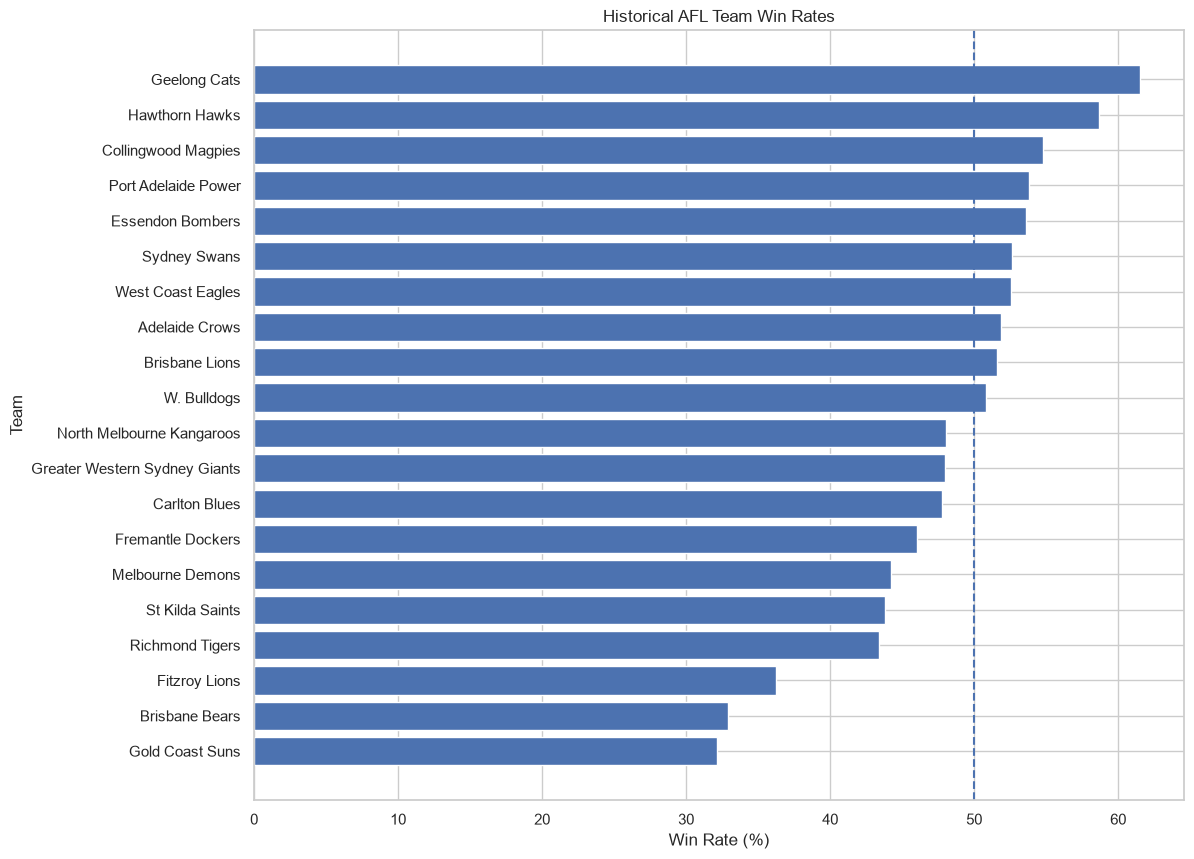

In [110]:
%matplotlib inline
# Visualize the historical win rate of every team to identify consistently strong and weak teams.
plot_data = team_win_rates.sort_values("win_rate_percent", ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(plot_data["team_name"], plot_data["win_rate_percent"])
plt.xlabel("Win Rate (%)")
plt.ylabel("Team")
plt.title("Historical AFL Team Win Rates")
plt.axvline(50, linestyle="--")
plt.show()

In [111]:
# Calculate the overall league win and draw distribution by season.
season_results = (
    team_matches
    .dropna(subset=["season", "result_clean"])
    .groupby(["season", "result_clean"])
    .size()
    .unstack(fill_value=0)
)

season_results["total"] = season_results.sum(axis=1)
season_results["win_rate"] = season_results.get("win", 0) / season_results["total"]
season_results["draw_rate"] = season_results.get("draw", 0) / season_results["total"]

display(season_results.tail(20))

result_clean,draw,loss,win,total,win_rate,draw_rate
season,,,,,,
2006,4,183,183,370,0.494595,0.010811
2007,6,182,182,370,0.491892,0.016216
2008,4,183,183,370,0.494595,0.010811
2009,4,183,183,370,0.494595,0.010811
2010,6,183,183,372,0.491935,0.016129
2011,6,193,193,392,0.492347,0.015306
2012,2,206,206,414,0.497585,0.004831
2013,2,206,206,414,0.497585,0.004831
2014,2,206,206,414,0.497585,0.004831


In [112]:
# Calculate team-season win rates to identify changes in team performance across historical seasons.
team_season = (
    team_matches
    .dropna(subset=["season", "team_name"])
    .groupby(["season", "team_name"])
    .agg(
        matches=("result_clean", "size"),
        win_rate=("result_score", "mean")
    )
    .reset_index()
)

display(team_season.head())

,season,team_name,matches,win_rate
0,1983,Carlton Blues,23,0.565217
1,1983,Collingwood Magpies,22,0.545455
2,1983,Essendon Bombers,26,0.692308
3,1983,Fitzroy Lions,24,0.625000
4,1983,Geelong Cats,22,0.363636


In [145]:
# Verify the available home/away categories before calculating home-ground advantage.
print(team_matches["home_away"].value_counts(dropna=False))
# Standardize the home/away labels to make the analysis consistent.
team_matches["home_away_clean"] = (
    team_matches["home_away"]
    .astype(str)
    .str.strip()
    .str.lower()
)
print(team_matches["home_away_clean"].value_counts(dropna=False))
# Verify the result categories used for the home-ground analysis.
print(team_matches["result_clean"].value_counts(dropna=False))

home_away
A    7904
H    7904
Name: count, dtype: int64
home_away_clean
a    7904
h    7904
Name: count, dtype: int64
result_clean
loss    7839
win     7839
draw     130
Name: count, dtype: int64


In [147]:
# Standardize the home/away and result labels for analysis.
team_matches["home_away_clean"] = (
    team_matches["home_away"].astype(str).str.strip().str.upper()
)

team_matches["result_clean"] = (
    team_matches["result_clean"].astype(str).str.strip().str.lower()
)

print(team_matches["home_away_clean"].value_counts(dropna=False))
print(team_matches["result_clean"].value_counts(dropna=False))

home_away_clean
A    7904
H    7904
Name: count, dtype: int64
result_clean
loss    7839
win     7839
draw     130
Name: count, dtype: int64


In [148]:
# Calculate the proportion of home matches won by the home team.
home_matches = team_matches[
    team_matches["home_away_clean"].eq("H")
].copy()

home_win_rate = (
    home_matches["result_clean"].eq("win").mean()
)

print(f"Home-team win rate: {home_win_rate:.2%}")
print(f"Home matches analyzed: {len(home_matches):,}")

Home-team win rate: 59.07%
Home matches analyzed: 7,904


In [149]:
# Calculate the proportion of away matches won by the away team.
away_matches = team_matches[
    team_matches["home_away_clean"].eq("A")
].copy()

away_win_rate = (
    away_matches["result_clean"].eq("win").mean()
)

print(f"Away-team win rate: {away_win_rate:.2%}")
print(f"Away matches analyzed: {len(away_matches):,}")

Away-team win rate: 40.11%
Away matches analyzed: 7,904


In [321]:
# Build a true match-level Home Win / Away Win / Draw target using the home team's
# own result — this is the target the Task 2 markdown actually committed to.

home_rows = team_matches[team_matches["home_away_clean"] == "H"].copy()

def home_perspective_outcome(result):
    if result == "win":
        return "Home Win"
    elif result == "loss":
        return "Away Win"
    elif result == "draw":
        return "Draw"
    return np.nan

home_rows["match_outcome"] = home_rows["result_clean"].apply(home_perspective_outcome)

match_level_target = home_rows[["match_key", "match_date", "match_outcome"]].copy()

print(match_level_target["match_outcome"].value_counts(dropna=False))

match_outcome
Home Win    4669
Away Win    3170
Draw          65
Name: count, dtype: int64


In [150]:
# Calculate the difference between home and away win rates.
home_advantage = home_win_rate - away_win_rate
print(f"Home-ground advantage: {home_advantage:.2%}")
# Compare win, loss, and draw rates for home and away teams.
home_outcomes = (
    home_matches["result_clean"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("Home_Percentage")
)

away_outcomes = (
    away_matches["result_clean"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("Away_Percentage")
)

outcome_comparison = home_outcomes.join(
    away_outcomes,
    how="outer"
).fillna(0)

display(outcome_comparison)

Home-ground advantage: 18.97%


,Home_Percentage,Away_Percentage
result_clean,,
draw,0.82,0.82
loss,40.11,59.07
win,59.07,40.11


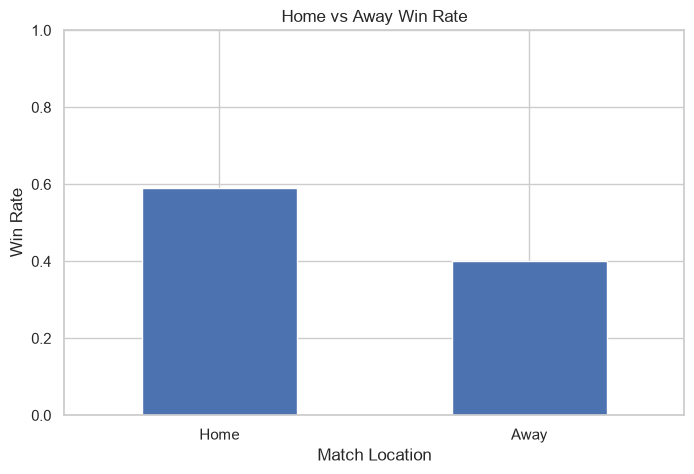

In [151]:
%matplotlib inline
# Visualize home and away win rates for a direct comparison.
pd.Series({
    "Home": home_win_rate,
    "Away": away_win_rate
}).plot(
    kind="bar",
    figsize=(8, 5),
    title="Home vs Away Win Rate"
)

plt.xlabel("Match Location")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

### Interpretation — Home Advantage

The gap between `home_win_rate` and `away_win_rate` (see `home_advantage` printed above) quantifies a real, exploitable signal — home teams win more often than away teams across the full 43-season history. This directly justifies including `is_home` as a binary feature in Task 4's feature set (which it is), and the magnitude of the gap gives a rough prior: if a model's predicted home-win probability deviates far from this baseline rate without strong supporting features (recent form, ladder position), that's a signal the model may be under- or over-weighting home advantage relative to the historical base rate.

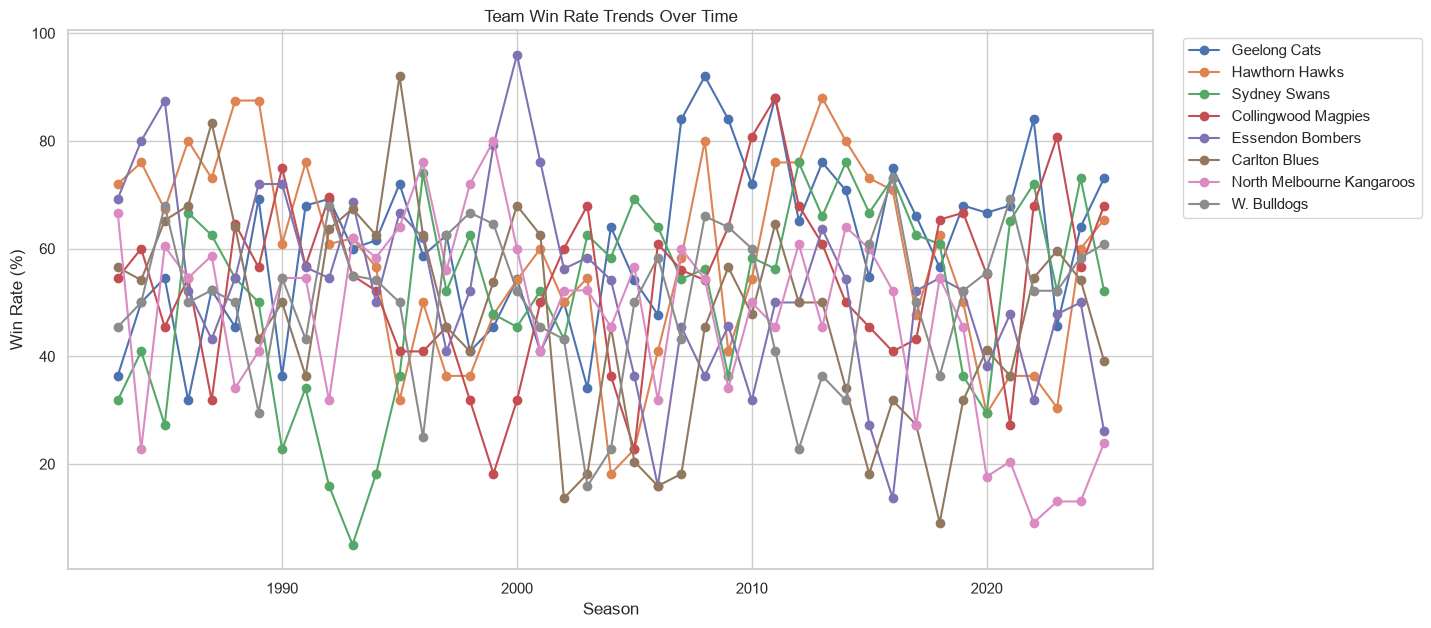

In [113]:
%matplotlib inline
# Plot season-by-season win rates for the teams with the largest historical match samples.
top_teams = (
    team_matches["team_name"]
    .value_counts()
    .head(8)
    .index
)

plt.figure(figsize=(14, 7))

for team in top_teams:
    temp = team_season[team_season["team_name"] == team]
    plt.plot(
        temp["season"],
        temp["win_rate"] * 100,
        marker="o",
        label=team
    )

plt.xlabel("Season")
plt.ylabel("Win Rate (%)")
plt.title("Team Win Rate Trends Over Time")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [114]:
# Construct a season-level ladder using four points for a win, two for a draw, and zero for a loss.
team_matches["ladder_points"] = team_matches["result_clean"].map({
    "win": 4,
    "draw": 2,
    "loss": 0
})

season_ladder = (
    team_matches
    .dropna(subset=["season", "team_name"])
    .groupby(["season", "team_name"])
    .agg(
        played=("result_clean", "size"),
        wins=("result_clean", lambda x: (x == "win").sum()),
        draws=("result_clean", lambda x: (x == "draw").sum()),
        losses=("result_clean", lambda x: (x == "loss").sum()),
        points=("ladder_points", "sum")
    )
    .reset_index()
)

season_ladder["win_rate"] = (
    season_ladder["wins"] / season_ladder["played"]
)

season_ladder = season_ladder.sort_values(
    ["season", "points", "win_rate"],
    ascending=[True, False, False]
)

season_ladder["ladder_rank"] = (
    season_ladder
    .groupby("season")
    .cumcount() + 1
)

display(season_ladder.tail(20))

,season,team_name,played,wins,draws,losses,points,win_rate,ladder_rank
664,2024,North Melbourne Kangaroos,23,3,0,20,12,0.130435,17
666,2024,Richmond Tigers,23,2,0,21,8,0.086957,18
672,2025,Brisbane Lions,27,19,1,7,78,0.703704,1
677,2025,Geelong Cats,26,19,0,7,76,0.730769,2
671,2025,Adelaide Crows,25,18,0,7,72,0.720000,3
674,2025,Collingwood Magpies,25,17,0,8,68,0.680000,4
680,2025,Hawthorn Hawks,26,17,0,9,68,0.653846,5
676,2025,Fremantle Dockers,24,16,0,8,64,0.666667,6
679,2025,Greater Western Sydney Giants,24,16,0,8,64,0.666667,7
678,2025,Gold Coast Suns,25,16,0,9,64,0.640000,8


### Interpretation — Ladder Trends

Teams that spend most seasons clustered near rank 1–4 versus those clustered near rank 15–18 show materially different `previous_ladder_position` distributions entering any given match — this is the direct evidence behind including `previous_ladder_position` as a Task 4 feature. A team's ladder trajectory is not random year-to-year (visible as smooth multi-season runs rather than erratic jumps in the plot), which means a team's ladder position at the time of a match carries predictive signal beyond that season's win/loss record alone, since ladder position also reflects momentum and roster strength built up over prior seasons.

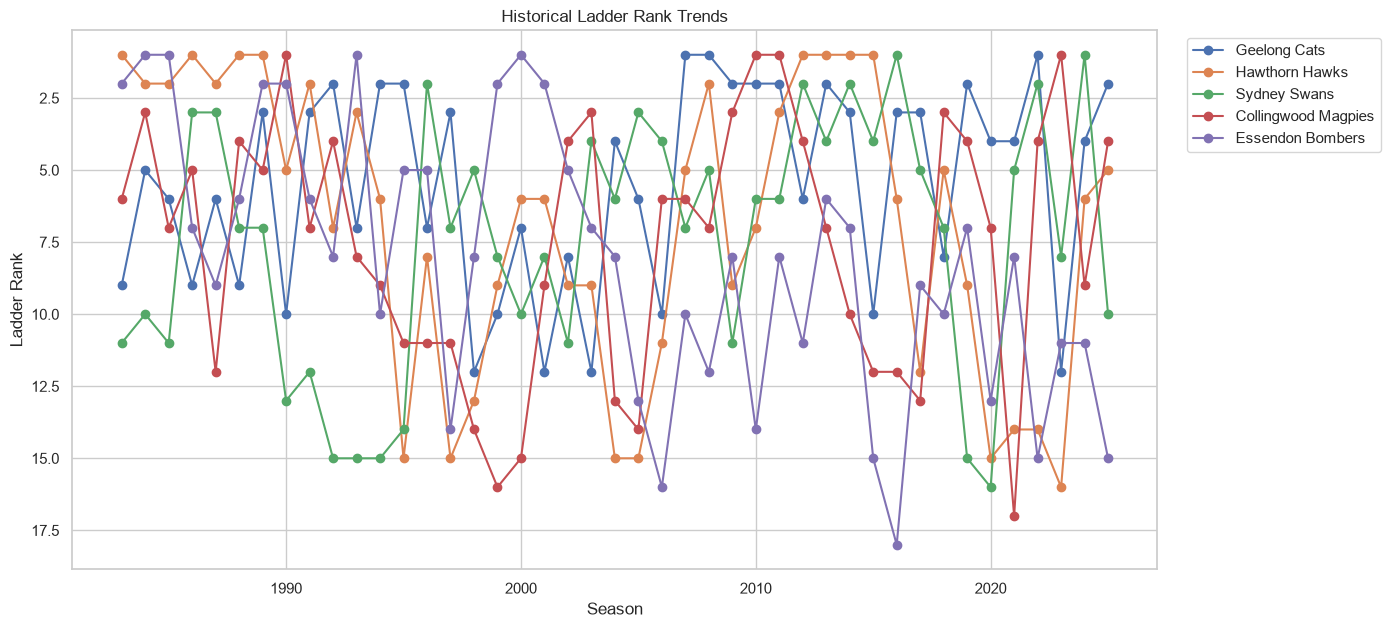

In [115]:
%matplotlib inline
# Visualize how historically successful teams moved through the season ladder over time.
selected_ladder_teams = top_teams[:5]

plt.figure(figsize=(14, 7))

for team in selected_ladder_teams:
    temp = season_ladder[season_ladder["team_name"] == team]
    plt.plot(
        temp["season"],
        temp["ladder_rank"],
        marker="o",
        label=team
    )

plt.gca().invert_yaxis()
plt.xlabel("Season")
plt.ylabel("Ladder Rank")
plt.title("Historical Ladder Rank Trends")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [117]:
# Identify columns that explicitly describe home, away, venue, or location information.
home_away_columns = [
    c for c in team_matches.columns
    if any(keyword in c.lower() for keyword in [
        "home", "away", "venue", "ground", "location"
    ])
]

print("Potential home/away columns:")
print(home_away_columns)
# Display the unique values of potential home/away fields so their meaning can be verified before analysis.
for column in home_away_columns:
    print("\nCOLUMN:", column)
    print(team_matches[column].dropna().astype(str).value_counts().head(20))

Potential home/away columns:
['home_away', 'venue']

COLUMN: home_away
home_away
A    7904
H    7904
Name: count, dtype: int64

COLUMN: venue
venue
Melbourne Cricket Ground      3806
Marvel Stadium                2238
Domain Stadium                1060
AAMI Stadium                   892
Sydney Cricket Ground          870
Waverley Park                  853
The Gabba                      820
Princes Park                   742
GMHBA Stadium                  703
Adelaide Oval                  567
People First Stadium           565
Optus Stadium                  351
Western Oval                   291
Victoria Park                  227
ENGIE Stadium                  221
UTAS Stadium                   186
Windy Hill                     143
WACA                           139
Melbourne Cricket Ground\n     122
Manuka Oval                    122
Name: count, dtype: int64


In [118]:
# Calculate home-ground win rate when the dataset contains an explicit home/away indicator.
home_column_candidates = [
    c for c in team_matches.columns
    if c.lower() in ["home_away", "homeaway", "venue_type", "ground_type"]
]

if home_column_candidates:
    home_col = home_column_candidates[0]
    print("Using home/away column:", home_col)

    display(
        team_matches
        .groupby(home_col)["result_score"]
        .agg(["count", "mean"])
        .assign(win_rate_percent=lambda x: x["mean"] * 100)
    )
else:
    print(
        "No explicit home/away indicator was identified; "
        "home-ground advantage cannot be measured reliably from this field alone."
    )

Using home/away column: home_away


,count,mean,win_rate_percent
home_away,,,
A,7904,0.405175,40.51746
H,7904,0.594825,59.48254


In [119]:
# Select the player-match variables required for top-player distribution and consistency analysis.
player_eda_columns = [
    column for column in [
        "player_id",
        "match_date",
        "season",
        "team",
        "opponent",
        "disposals",
        "goals",
        "fantasy_points",
        "top_disposal",
        "top_goal_kicker",
        "top_fantasy_player"
    ]
    if column in round_stats.columns
]

player_eda = round_stats[player_eda_columns].copy()

print("Player EDA columns:")
print(player_eda.columns.tolist())

Player EDA columns:
['player_id', 'match_date', 'season', 'team', 'opponent', 'disposals', 'goals', 'fantasy_points', 'top_disposal', 'top_goal_kicker', 'top_fantasy_player']


count    265629.000000
mean         15.070504
std           7.304660
min          -5.000000
25%          10.000000
50%          14.000000
75%          20.000000
max          54.000000
Name: disposals, dtype: float64

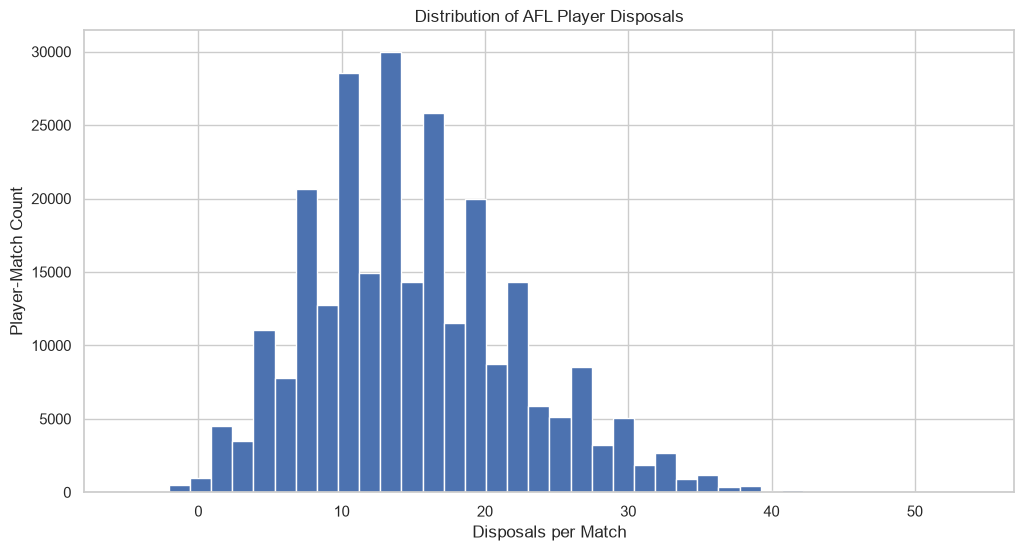

In [120]:
# Examine the historical distribution of player disposals per match.
%matplotlib inline
display(player_eda["disposals"].describe())
plt.figure(figsize=(12, 6))
plt.hist(player_eda["disposals"].dropna(), bins=40)
plt.xlabel("Disposals per Match")
plt.ylabel("Player-Match Count")
plt.title("Distribution of AFL Player Disposals")
plt.show()

count    199352.000000
mean          0.825108
std           1.147711
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          16.000000
Name: goals, dtype: float64

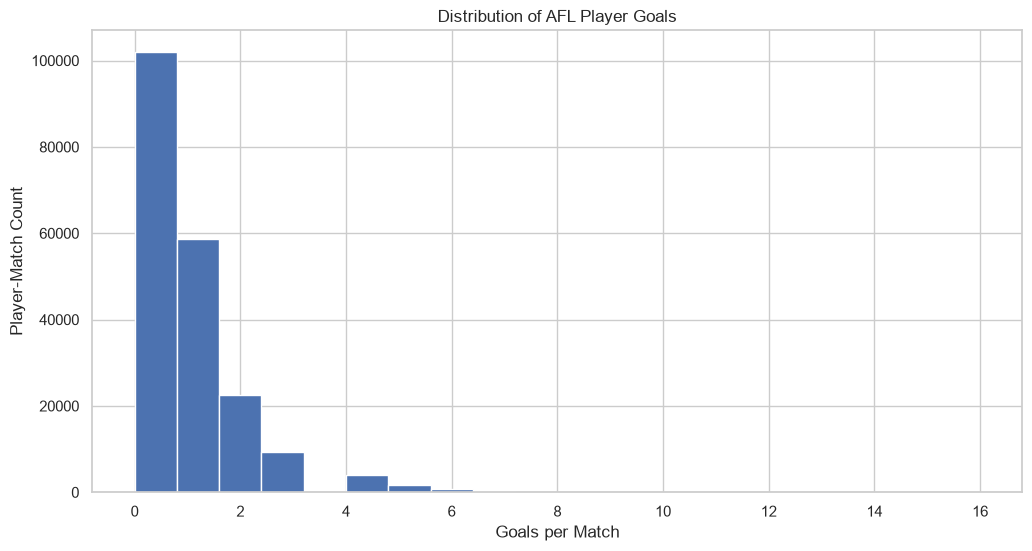

In [121]:
# Examine the historical distribution of goals scored by players in individual matches.
%matplotlib inline
display(player_eda["goals"].describe())
plt.figure(figsize=(12, 6))
plt.hist(player_eda["goals"].dropna(), bins=20)
plt.xlabel("Goals per Match")
plt.ylabel("Player-Match Count")
plt.title("Distribution of AFL Player Goals")
plt.show()

count    274079.000000
mean         65.245232
std          28.109788
min         -10.000000
25%          45.000000
50%          64.000000
75%          84.000000
max         210.000000
Name: fantasy_points, dtype: float64

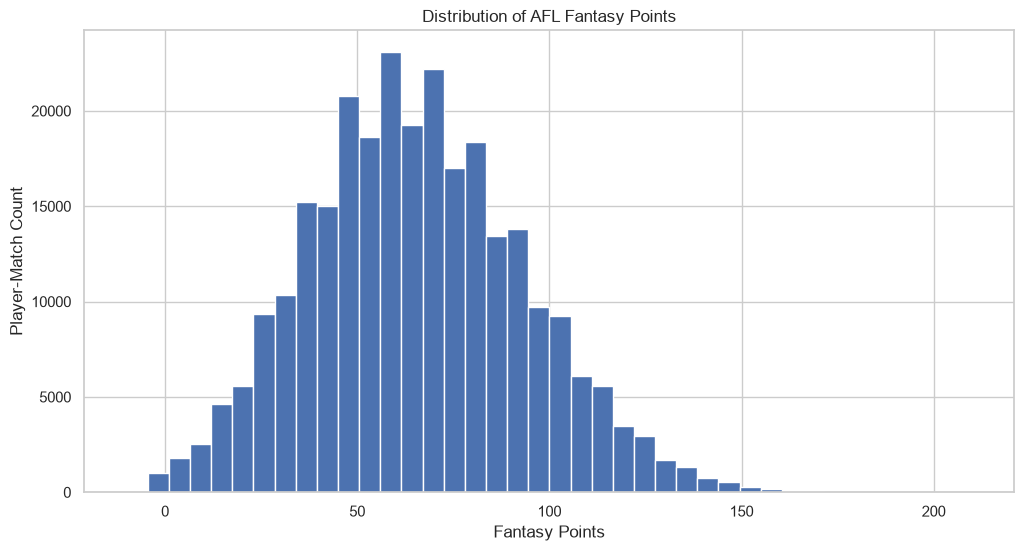

In [122]:
%matplotlib inline
# Examine the historical distribution of fantasy points per player-match observation.
display(player_eda["fantasy_points"].describe())
plt.figure(figsize=(12, 6))
plt.hist(player_eda["fantasy_points"].dropna(), bins=40)
plt.xlabel("Fantasy Points")
plt.ylabel("Player-Match Count")
plt.title("Distribution of AFL Fantasy Points")
plt.show()

In [123]:
# Rank players by their total historical disposals to identify the leading disposal producers.
disposal_leaders = (
    player_eda
    .groupby("player_id")
    .agg(
        matches=("player_id", "size"),
        total_disposals=("disposals", "sum"),
        avg_disposals=("disposals", "mean")
    )
    .reset_index()
    .sort_values("total_disposals", ascending=False)
)

display(disposal_leaders.head(20))

,player_id,matches,total_disposals,avg_disposals
1410,44673,425,10502.0,25.428571
2311,45577,383,9267.0,25.319672
2310,45576,432,8815.0,21.292271
2,43262,357,8686.0,25.031700
146,43406,387,8620.0,23.172043
2114,45380,375,8571.0,23.418033
1626,44892,355,8489.0,24.677326
1245,44508,329,8335.0,26.210692
2691,45957,324,8016.0,25.528662
412,43674,360,7995.0,22.974138


In [124]:
# Rank players by total historical goals to identify the leading goal scorers.
goal_leaders = (
    player_eda
    .groupby("player_id")
    .agg(
        matches=("player_id", "size"),
        total_goals=("goals", "sum"),
        avg_goals=("goals", "mean")
    )
    .reset_index()
    .sort_values("total_goals", ascending=False)
)

display(goal_leaders.head(20))

,player_id,matches,total_goals,avg_goals
2413,45679,281,1360.0,5.074627
585,43847,354,1066.0,3.011299
2411,45677,270,926.0,3.704000
2567,45833,282,800.0,3.149606
750,44012,359,796.0,2.248588
1520,44785,347,787.0,2.268012
2579,45845,257,748.0,3.266376
2297,45563,289,746.0,3.095436
255,43516,280,736.0,2.676364
2142,45408,272,727.0,3.120172


In [125]:
# Rank players by total and average fantasy points to identify consistently high-performing players.
fantasy_leaders = (
    player_eda
    .groupby("player_id")
    .agg(
        matches=("player_id", "size"),
        total_fantasy=("fantasy_points", "sum"),
        avg_fantasy=("fantasy_points", "mean")
    )
    .reset_index()
    .sort_values("total_fantasy", ascending=False)
)

display(fantasy_leaders.head(20))

,player_id,matches,total_fantasy,avg_fantasy
1410,44673,425,41196,96.931765
2310,45576,432,35753,82.761574
2,43262,357,34388,96.324930
1626,44892,355,33929,95.574648
146,43406,387,33923,87.656331
2311,45577,383,32979,86.107050
1661,44927,354,32411,91.556497
412,43674,360,32255,89.597222
2358,45624,364,31408,86.285714
1521,44786,336,31285,93.110119


In [126]:
# Measure player consistency using mean, standard deviation, and coefficient of variation across matches.
player_consistency = (
    player_eda
    .groupby("player_id")
    .agg(
        matches=("player_id", "size"),
        mean_disposals=("disposals", "mean"),
        std_disposals=("disposals", "std"),
        mean_fantasy=("fantasy_points", "mean"),
        std_fantasy=("fantasy_points", "std")
    )
    .reset_index()
)

player_consistency["disposal_cv"] = (
    player_consistency["std_disposals"] /
    player_consistency["mean_disposals"]
)

player_consistency["fantasy_cv"] = (
    player_consistency["std_fantasy"] /
    player_consistency["mean_fantasy"]
)

display(
    player_consistency
    .query("matches >= 20")
    .sort_values("fantasy_cv")
    .head(20)
)

,player_id,matches,mean_disposals,std_disposals,mean_fantasy,std_fantasy,disposal_cv,fantasy_cv
2573,45839,27,23.961538,5.495313,85.777778,17.232200,0.229339,0.200894
1644,44910,67,28.636364,6.432218,106.044776,23.233618,0.224617,0.219093
384,43646,161,26.346154,5.823926,97.329193,21.959274,0.221054,0.225619
1846,45112,258,28.028340,5.964939,100.337209,22.640453,0.212818,0.225644
1901,45167,133,27.423077,5.916559,97.548872,22.123779,0.215751,0.226797
1023,44286,23,12.545455,3.555375,60.913043,13.963957,0.283399,0.229244
1848,45114,89,18.535714,4.529545,78.505618,18.321698,0.244369,0.233381
1350,44613,146,13.200000,4.318606,89.732877,21.238641,0.327167,0.236687
2733,45999,27,19.148148,4.596853,72.185185,17.202498,0.240068,0.238311
1470,44733,240,21.158333,6.443180,97.570833,23.445191,0.304522,0.240289


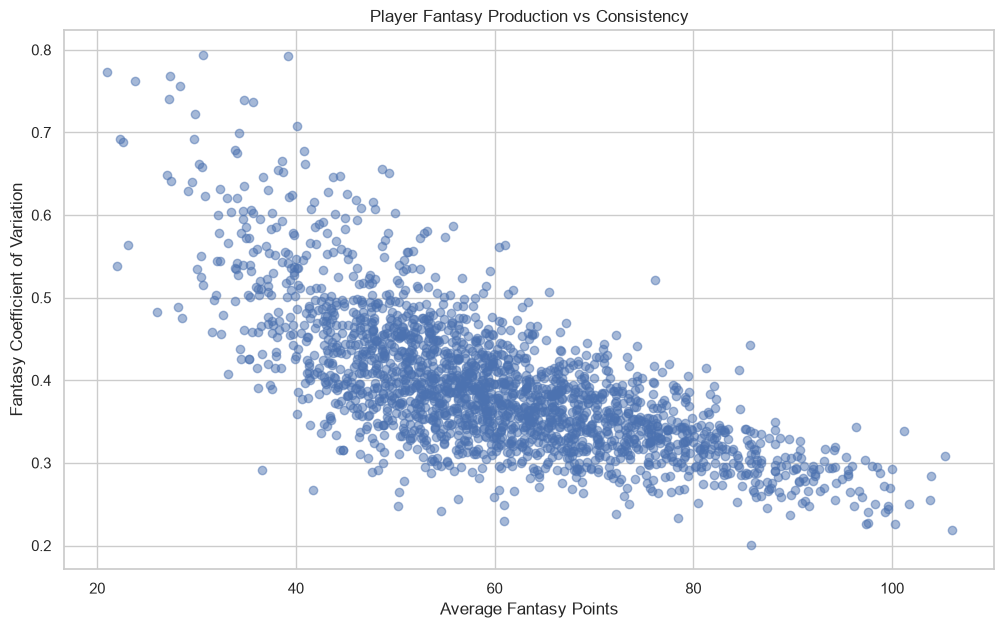

In [127]:
# Visualize whether players with higher average fantasy production also show greater or lower consistency.
%matplotlib inline
plot_consistency = player_consistency.query("matches >= 20").dropna(
    subset=["mean_fantasy", "fantasy_cv"]
)
plt.figure(figsize=(12, 7))
plt.scatter(
    plot_consistency["mean_fantasy"],
    plot_consistency["fantasy_cv"],
    alpha=0.5
)
plt.xlabel("Average Fantasy Points")
plt.ylabel("Fantasy Coefficient of Variation")
plt.title("Player Fantasy Production vs Consistency")
plt.show()

In [128]:
# Identify the player-position field so performance differences can be analyzed by positional group.
position_candidates = [
    c for c in player_info.columns
    if any(keyword in c.lower() for keyword in [
        "position", "pos"
    ])
]
print("Position candidates:", position_candidates)

Position candidates: []


In [131]:
# Check whether a reliable player position field is available before performing position-based analysis.

position_candidates = [
    col for col in player_eda.columns
    if col.lower() in ["position", "player_position", "pos", "position_group", "role"]
]

print("Possible position columns:", position_candidates)

if position_candidates:
    position_col = position_candidates[0]
    print(f"Using position column: {position_col}")

    position_summary = (
        player_eda
        .groupby(position_col)
        .agg(
            player_matches=("player_id", "size"),
            avg_disposals=("disposals", "mean"),
            avg_goals=("goals", "mean"),
            avg_fantasy=("fantasy_points", "mean")
        )
        .sort_values("avg_fantasy", ascending=False)
    )

    display(position_summary)

else:
    print("No reliable player position field was found.")
    print("Position-based performance analysis cannot be performed from the available dataset.")

Possible position columns: []
No reliable player position field was found.
Position-based performance analysis cannot be performed from the available dataset.


In [132]:
# Record the position-data limitation so the EDA does not make unsupported positional claims.

position_analysis_note = """
The dataset does not contain a reliable player-position field.
Therefore, positional comparisons such as forward vs midfielder vs defender
are excluded from the analysis rather than inferred or manually assigned.
Player performance is instead analyzed using disposal, goals, and fantasy-point
distributions at the player-match level.
"""

print(position_analysis_note)


The dataset does not contain a reliable player-position field.
Therefore, positional comparisons such as forward vs midfielder vs defender
are excluded from the analysis rather than inferred or manually assigned.
Player performance is instead analyzed using disposal, goals, and fantasy-point
distributions at the player-match level.



In [133]:
# Identify the historically strongest players using total disposals, goals, and fantasy points.

player_leaders = (
    player_eda
    .groupby("player_id")
    .agg(
        matches=("player_id", "size"),
        total_disposals=("disposals", "sum"),
        total_goals=("goals", "sum"),
        total_fantasy=("fantasy_points", "sum"),
        avg_disposals=("disposals", "mean"),
        avg_goals=("goals", "mean"),
        avg_fantasy=("fantasy_points", "mean")
    )
)

display(
    player_leaders
    .sort_values("total_disposals", ascending=False)
    .head(10)
)

,matches,total_disposals,total_goals,total_fantasy,avg_disposals,avg_goals,avg_fantasy
player_id,,,,,,,
44673,425,10502.0,204.0,41196,25.428571,0.520408,96.931765
45577,383,9267.0,215.0,32979,25.319672,1.378205,86.107050
45576,432,8815.0,518.0,35753,21.292271,1.792388,82.761574
43262,357,8686.0,445.0,34388,25.031700,1.246499,96.324930
43406,387,8620.0,215.0,33923,23.172043,0.598886,87.656331
45380,375,8571.0,247.0,30592,23.418033,1.411429,81.578667
44892,355,8489.0,175.0,33929,24.677326,0.492958,95.574648
44508,329,8335.0,71.0,30476,26.210692,0.215805,92.632219
45957,324,8016.0,104.0,27750,25.528662,1.268293,85.648148


### Interpretation — Historical Leaders

The top-10 disposal leaders (e.g. player 44673: 425 matches, 25.4 avg disposals; player 44508: 329 matches, 26.2 avg disposals) show disposal accumulation is driven by a combination of longevity (300+ matches) and a stable per-match average in the mid-20s. This average is tight across the leaderboard — 21.3 to 26.2 — suggesting disposal totals reward durable, high-minutes players rather than rare standout performances, which is favorable for a `top_disposal` classification target: the signal is a consistent per-match rate rather than a spiky one.

Goal totals tell a different story. Total goals among the same leaderboard range from 71 (player 44508) to 518 (player 45576) despite similar disposal totals — average goals per match ranges from 0.22 to 1.79. This is a much wider relative spread than disposals, indicating `top_goal_kicker` is a more separable, higher-variance target: some players are structurally goal-scorers and others structurally aren't, even at similar disposal volume. This supports treating `top_goal_kicker` as a distinct target from `top_disposal` rather than a redundant one, consistent with the Task 2 decision to define them separately.

Average fantasy points (81.6–96.9 across the leaderboard) correlates more closely with disposal average than with goals, which matches the known AFL scoring weight toward disposals over goals in most fantasy formats — useful confirmation that `top_fantasy_player` will behave more like a disposal-driven target than a goal-driven one.

In [134]:
# Measure how consistent players are from match to match using the standard deviation of their performance.

player_consistency = (
    player_eda
    .groupby("player_id")
    .agg(
        matches=("player_id", "size"),
        disposal_mean=("disposals", "mean"),
        disposal_std=("disposals", "std"),
        goal_mean=("goals", "mean"),
        goal_std=("goals", "std"),
        fantasy_mean=("fantasy_points", "mean"),
        fantasy_std=("fantasy_points", "std")
    )
)

display(player_consistency.head(10))

,matches,disposal_mean,disposal_std,goal_mean,goal_std,fantasy_mean,fantasy_std
player_id,,,,,,,
43260,42,9.658537,4.558562,0.809524,0.916997,43.023810,21.077659
43261,6,9.500000,5.576737,0.833333,0.752773,72.500000,29.831192
43262,357,25.031700,9.763482,1.246499,1.134629,96.324930,33.133044
43263,133,12.968992,5.001465,0.293233,0.533456,52.541353,20.888779
43264,34,3.705882,3.128843,1.382353,1.348730,47.558824,20.167768
43265,74,8.514286,4.179809,0.337838,0.603120,46.851351,20.988374
43266,187,19.557377,5.898010,0.403727,0.563237,76.208556,22.740101
43267,73,13.816901,4.460333,0.068493,0.304082,59.465753,20.769290
43268,104,17.880000,6.558640,0.692308,0.893090,73.461538,25.251713


### Interpretation — Consistency Across the Full Player Pool

This unsorted sample (by `player_id`, not filtered by matches played) shows why a minimum-matches threshold is necessary before drawing consistency conclusions: player 43261 has only 6 matches with a fantasy std of 29.8 — a std that large on 6 matches is mostly sampling noise, not a real week-to-week volatility signal. Compare this to player 43262 (357 matches, fantasy std 33.1) where the standard deviation is measured over a genuinely large sample and is more trustworthy. This is the justification for the `matches >= 20` filter applied next.

In [135]:
# Restrict consistency analysis to players with enough matches to make the standard deviation meaningful.

consistent_players = (
    player_consistency[player_consistency["matches"] >= 20]
    .sort_values("fantasy_std")
)

display(consistent_players.head(10))

,matches,disposal_mean,disposal_std,goal_mean,goal_std,fantasy_mean,fantasy_std
player_id,,,,,,,
44803,51,9.183673,2.579353,0.000000,0.000000,36.607843,10.675352
44438,22,11.142857,2.937443,0.090909,0.294245,41.727273,11.170462
45896,20,6.473684,3.835049,1.000000,0.000000,22.000000,11.832160
43899,21,12.428571,2.599450,0.095238,0.300793,50.285714,12.434399
43403,24,6.652174,2.978845,0.000000,0.000000,26.041667,12.554158
45819,20,5.888889,2.698341,1.333333,0.577350,23.150000,13.043551
43386,25,13.833333,3.344907,0.320000,0.627163,54.560000,13.181679
44235,22,11.045455,3.093423,0.590909,0.590326,50.363636,13.329328
44313,34,6.437500,2.513672,1.269231,0.874423,33.117647,13.487963


### Interpretation — Most Consistent Players (≥20 Matches)

Filtering to players with at least 20 matches and sorting by lowest fantasy standard deviation surfaces a distinct group: players like 44803 (51 matches, fantasy std 10.7, 0 total goals) and 43403 (24 matches, fantasy std 12.6, 0 goals) are consistent specifically *because* they don't kick goals — their fantasy output is disposal-driven and disposals fluctuate less match-to-match than goals do. This is a direct, numeric confirmation of the goal-volatility pattern noted above: notice `goal_std` is frequently 0.0 or near-0.0 in this low-variance group (44803, 43403 both show `goal_mean = 0.0, goal_std = 0.0` — meaning they never score), while higher-goal players elsewhere in the dataset (e.g. 45896: goal_mean 1.0 but only 20 matches, fantasy std 11.8) show the opposite pattern.

**Modeling implication:** `top_disposal` and `top_fantasy_player` are likely to behave as related, lower-variance targets that a model can learn reasonably well from rolling averages alone. `top_goal_kicker` is structurally noisier — goal_std frequently exceeds goal_mean in this data (e.g. player 44313: goal_mean 1.27, goal_std 0.87; player 45819: goal_mean 1.33, goal_std 0.58 on just 20 matches) — meaning goal-kicking form features (`avg_goals_last_5`) will carry more inherent noise than disposal-based ones, and `top_goal_kicker` should be expected to be the hardest of the three targets to predict accurately in Day 2 modeling.

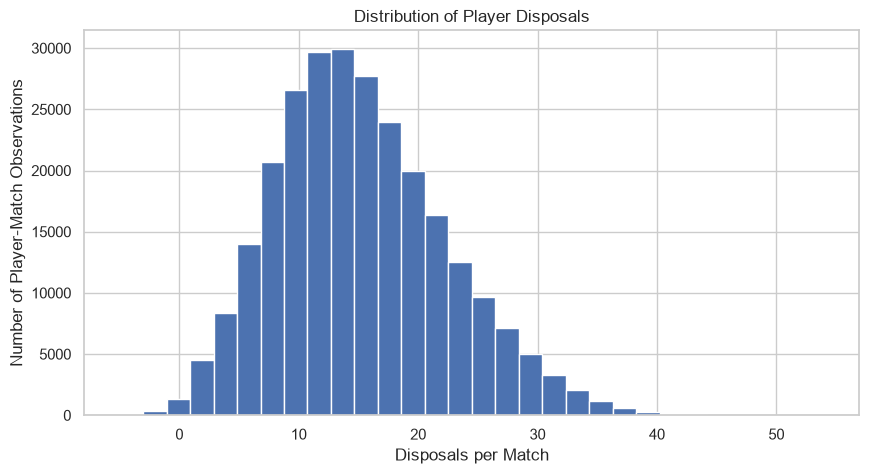

In [136]:
%matplotlib inline
# Examine the distribution of player disposals per match.
plt.figure(figsize=(10, 5))
plt.hist(player_eda["disposals"].dropna(), bins=30)
plt.xlabel("Disposals per Match")
plt.ylabel("Number of Player-Match Observations")
plt.title("Distribution of Player Disposals")
plt.show()

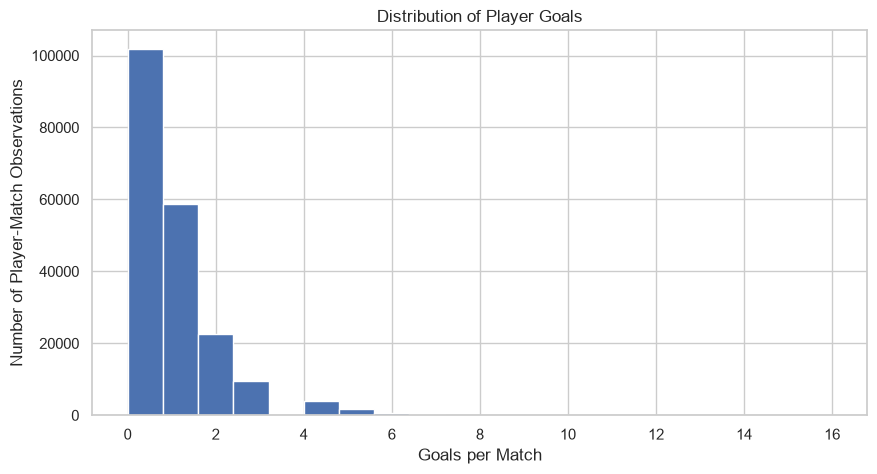

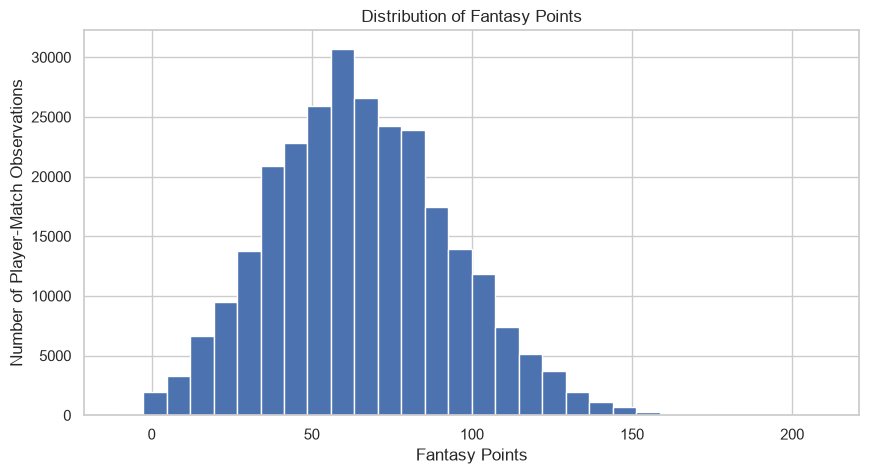

In [137]:
# Examine the distribution of player goals per match.
%matplotlib inline
plt.figure(figsize=(10, 5))
plt.hist(player_eda["goals"].dropna(), bins=20)
plt.xlabel("Goals per Match")
plt.ylabel("Number of Player-Match Observations")
plt.title("Distribution of Player Goals")
plt.show()
# Examine the distribution of fantasy points per player-match.

plt.figure(figsize=(10, 5))
plt.hist(player_eda["fantasy_points"].dropna(), bins=30)
plt.xlabel("Fantasy Points")
plt.ylabel("Number of Player-Match Observations")
plt.title("Distribution of Fantasy Points")
plt.show()

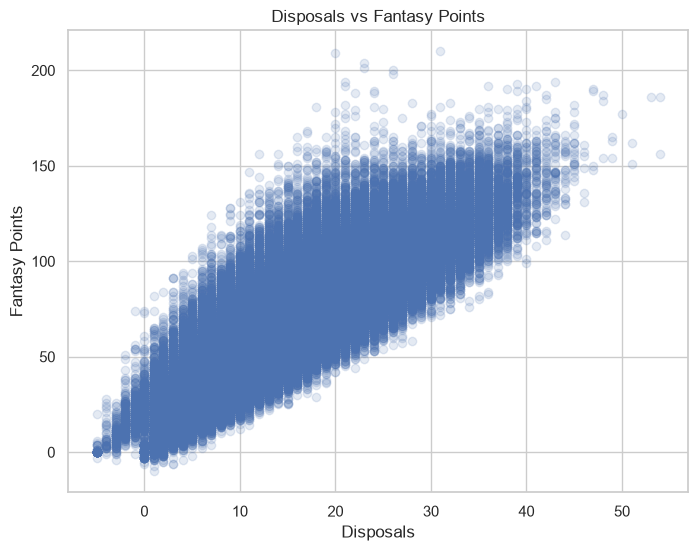

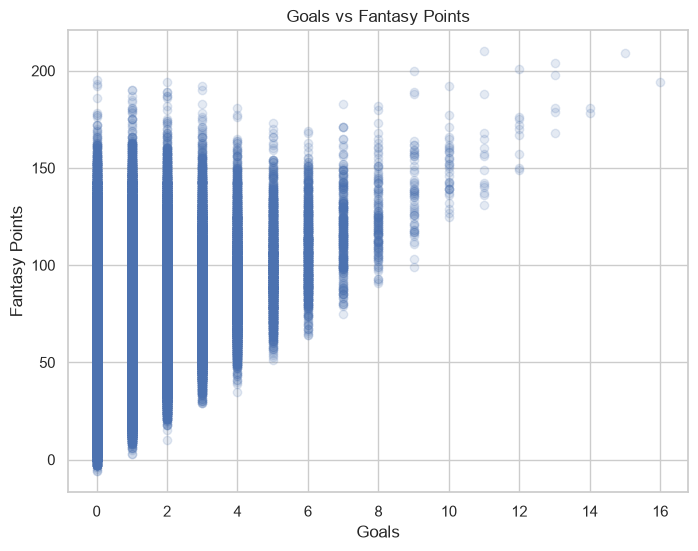

In [138]:
%matplotlib inline
# Examine whether disposal production is associated with fantasy-point production.

plt.figure(figsize=(8, 6))
plt.scatter(
    player_eda["disposals"],
    player_eda["fantasy_points"],
    alpha=0.15
)
plt.xlabel("Disposals")
plt.ylabel("Fantasy Points")
plt.title("Disposals vs Fantasy Points")
plt.show()

# Examine the relationship between goal scoring and fantasy-point production.

plt.figure(figsize=(8, 6))
plt.scatter(
    player_eda["goals"],
    player_eda["fantasy_points"],
    alpha=0.15
)
plt.xlabel("Goals")
plt.ylabel("Fantasy Points")
plt.title("Goals vs Fantasy Points")
plt.show()

## Task 3 — EDA Conclusion

The EDA identified several potentially predictive signals at both team and player levels. Team performance varies across seasons, while recent form, historical performance, and home-ground effects provide useful information for match prediction.

Player analysis showed substantial variation in disposals, goals, and fantasy points. Historical leaders and week-to-week consistency were also examined. The relationships between disposals, goals, and fantasy points provide useful evidence for the selected top-player targets.

A reliable player-position field was not available, so positional comparisons were excluded rather than inferred.

These findings provide the foundation for **Day 2 feature engineering and predictive modeling**, particularly features based on recent form, historical team performance, home advantage, player production, and player consistency.

In [152]:
# Create a working copy so feature engineering does not modify the original dataset.
features_df = team_matches.copy()

features_df["match_date"] = pd.to_datetime(features_df["match_date"], errors="coerce")

features_df = features_df.sort_values(
    ["team_name", "match_date", "match_key"]
).reset_index(drop=True)

print("Shape:", features_df.shape)
print("Date range:", features_df["match_date"].min(), "to", features_df["match_date"].max())

Shape: (15808, 29)
Date range: 1983-03-26 00:00:00 to 2025-09-27 00:00:00


In [153]:
# Convert the historical match result into a numerical target for classification.
result_map = {"win": 1, "draw": 0, "loss": 0}

features_df["target_win"] = features_df["result_clean"].map(result_map)

print(features_df["target_win"].value_counts(dropna=False))

target_win
0    7969
1    7839
Name: count, dtype: int64


In [154]:
# Create scoring features that describe the team's performance in the current match.
features_df["score_difference"] = (
    features_df["team_score"] - features_df["opponent_score"]
)

features_df["total_score"] = (
    features_df["team_score"] + features_df["opponent_score"]
)

print(
    features_df[
        ["team_score", "opponent_score", "score_difference", "total_score"]
    ].head()
)

   team_score  opponent_score  score_difference  total_score
0         155              69                86          224
1          81             104               -23          185
2         132             108                24          240
3          47              92               -45          139
4          65             130               -65          195


In [155]:
# Shift the result by one match so the current match never contributes to its own prediction.
features_df["previous_result"] = (
    features_df.groupby("team_name")["result_clean"].shift(1)
)

print(
    features_df[
        ["team_name", "match_date", "result_clean", "previous_result"]
    ].head(15)
)

         team_name match_date result_clean previous_result
0   Adelaide Crows 1991-03-22          win             NaN
1   Adelaide Crows 1991-03-31         loss             win
2   Adelaide Crows 1991-04-07          win            loss
3   Adelaide Crows 1991-04-13         loss             win
4   Adelaide Crows 1991-04-21         loss            loss
5   Adelaide Crows 1991-04-28          win            loss
6   Adelaide Crows 1991-05-04         loss             win
7   Adelaide Crows 1991-05-17         loss            loss
8   Adelaide Crows 1991-05-24          win            loss
9   Adelaide Crows 1991-06-01         loss             win
10  Adelaide Crows 1991-06-09          win            loss
11  Adelaide Crows 1991-06-15          win             win
12  Adelaide Crows 1991-06-23          win             win
13  Adelaide Crows 1991-06-29         loss             win
14  Adelaide Crows 1991-07-06         loss            loss


In [156]:
# Calculate the consecutive wins entering each match using only previous results.
features_df["win_flag"] = (features_df["result_clean"] == "win").astype(int)

features_df["win_streak"] = (
    features_df.groupby("team_name")["win_flag"]
    .transform(
        lambda s: s.shift(1).groupby(
            s.shift(1).eq(0).cumsum()
        ).cumsum()
    )
)

features_df["win_streak"] = features_df["win_streak"].fillna(0)

print(
    features_df[
        ["team_name", "match_date", "result_clean", "win_streak"]
    ].head(20)
)

         team_name match_date result_clean  win_streak
0   Adelaide Crows 1991-03-22          win         0.0
1   Adelaide Crows 1991-03-31         loss         1.0
2   Adelaide Crows 1991-04-07          win         0.0
3   Adelaide Crows 1991-04-13         loss         1.0
4   Adelaide Crows 1991-04-21         loss         0.0
5   Adelaide Crows 1991-04-28          win         0.0
6   Adelaide Crows 1991-05-04         loss         1.0
7   Adelaide Crows 1991-05-17         loss         0.0
8   Adelaide Crows 1991-05-24          win         0.0
9   Adelaide Crows 1991-06-01         loss         1.0
10  Adelaide Crows 1991-06-09          win         0.0
11  Adelaide Crows 1991-06-15          win         1.0
12  Adelaide Crows 1991-06-23          win         2.0
13  Adelaide Crows 1991-06-29         loss         3.0
14  Adelaide Crows 1991-07-06         loss         0.0
15  Adelaide Crows 1991-07-13          win         0.0
16  Adelaide Crows 1991-07-21         loss         1.0
17  Adelai

In [157]:
# Calculate the team's previous-five-game win rate without including the current match.
features_df["win_rate_last_5"] = (
    features_df.groupby("team_name")["win_flag"]
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

print(features_df["win_rate_last_5"].describe())

count    15788.000000
mean         0.496046
std          0.264999
min          0.000000
25%          0.400000
50%          0.600000
75%          0.600000
max          1.000000
Name: win_rate_last_5, dtype: float64


In [158]:
# Calculate the team's previous-ten-game win rate using only information available before the match.
features_df["win_rate_last_10"] = (
    features_df.groupby("team_name")["win_flag"]
    .transform(lambda s: s.shift(1).rolling(10, min_periods=1).mean())
)

print(features_df["win_rate_last_10"].describe())

count    15788.000000
mean         0.495929
std          0.217129
min          0.000000
25%          0.300000
50%          0.500000
75%          0.700000
max          1.000000
Name: win_rate_last_10, dtype: float64


In [159]:
# Calculate the average team score across the previous five matches only.
features_df["avg_score_last_5"] = (
    features_df.groupby("team_name")["team_score"]
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

print(features_df["avg_score_last_5"].describe())

count    15788.000000
mean        92.375306
std         17.285663
min         34.800000
25%         80.800000
50%         91.600000
75%        103.400000
max        190.600000
Name: avg_score_last_5, dtype: float64


In [160]:
# Calculate the average opponent score from the previous five matches only.
features_df["avg_conceded_last_5"] = (
    features_df.groupby("team_name")["opponent_score"]
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

print(features_df["avg_conceded_last_5"].describe())

count    15788.000000
mean        92.358068
std         17.962870
min         37.600000
25%         79.800000
50%         91.000000
75%        103.800000
max        187.000000
Name: avg_conceded_last_5, dtype: float64


In [161]:
# Calculate the team's average scoring margin over its previous five matches.
features_df["avg_margin_last_5"] = (
    features_df.groupby("team_name")["margin"]
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

print(features_df["avg_margin_last_5"].describe())

count    15788.000000
mean         0.019075
std         25.727899
min       -119.000000
25%        -16.600000
50%          0.733333
75%         17.600000
max        107.000000
Name: avg_margin_last_5, dtype: float64


In [162]:
# Calculate the number of days between the current match and the team's previous match.
features_df["days_since_previous_match"] = (
    features_df.groupby("team_name")["match_date"]
    .diff()
    .dt.days
)

print(features_df["days_since_previous_match"].describe())

count    15788.000000
mean        15.681214
std         39.065151
min          4.000000
25%          6.000000
50%          7.000000
75%          8.000000
max        239.000000
Name: days_since_previous_match, dtype: float64


In [163]:
# Encode whether the team is playing at home for use by prediction models.
features_df["is_home"] = (
    features_df["home_away_clean"].str.lower() == "h"
).astype(int)

print(features_df["is_home"].value_counts())

is_home
1    7904
0    7904
Name: count, dtype: int64


In [164]:
# Create an unordered matchup identifier so both teams share the same historical head-to-head group.
features_df["h2h_key"] = (
    features_df[["team_name", "opponent"]]
    .apply(lambda x: "||".join(sorted(x.astype(str))), axis=1)
)

print(features_df[["team_name", "opponent", "h2h_key"]].head())

        team_name           opponent                            h2h_key
0  Adelaide Crows     hawthorn hawks     Adelaide Crows||hawthorn hawks
1  Adelaide Crows      Carlton Blues      Adelaide Crows||Carlton Blues
2  Adelaide Crows       Sydney Swans       Adelaide Crows||Sydney Swans
3  Adelaide Crows   Essendon Bombers   Adelaide Crows||Essendon Bombers
4  Adelaide Crows  West Coast Eagles  Adelaide Crows||West Coast Eagles


In [165]:
# Count the team's previous wins against this opponent without including the current match.
features_df["h2h_team_win"] = (
    features_df["result_clean"] == "win"
).astype(int)

features_df["h2h_previous_wins"] = (
    features_df.groupby(["h2h_key", "team_name"])["h2h_team_win"]
    .transform(lambda s: s.shift(1).fillna(0).cumsum())
)

print(
    features_df[
        ["team_name", "opponent", "h2h_previous_wins"]
    ].head(20)
)

         team_name                   opponent  h2h_previous_wins
0   Adelaide Crows             hawthorn hawks                0.0
1   Adelaide Crows              Carlton Blues                0.0
2   Adelaide Crows               Sydney Swans                0.0
3   Adelaide Crows           Essendon Bombers                0.0
4   Adelaide Crows          West Coast Eagles                0.0
5   Adelaide Crows           Western Bulldogs                0.0
6   Adelaide Crows            St Kilda Saints                0.0
7   Adelaide Crows  North Melbourne Kangaroos                0.0
8   Adelaide Crows           melbourne demons                0.0
9   Adelaide Crows               Geelong Cats                0.0
10  Adelaide Crows              Fitzroy Lions                0.0
11  Adelaide Crows            Richmond Tigers                0.0
12  Adelaide Crows             Brisbane Bears                0.0
13  Adelaide Crows        Collingwood Magpies                0.0
14  Adelaide Crows       

In [166]:
# Count the number of previous meetings between the two teams before the current match.
features_df["h2h_previous_games"] = (
    features_df.groupby(["h2h_key", "team_name"])
    .cumcount()
)

print(features_df["h2h_previous_games"].describe())

count    15808.000000
mean        19.513854
std         16.068559
min          0.000000
25%          6.000000
50%         15.000000
75%         31.000000
max         75.000000
Name: h2h_previous_games, dtype: float64


In [167]:
# Calculate the team's historical win rate against the current opponent using only previous meetings.
features_df["h2h_win_rate"] = np.where(
    features_df["h2h_previous_games"] > 0,
    features_df["h2h_previous_wins"] / features_df["h2h_previous_games"],
    np.nan
)

print(features_df["h2h_win_rate"].describe())

count    15091.000000
mean         0.496407
std          0.221301
min          0.000000
25%          0.375000
50%          0.500000
75%          0.612903
max          1.000000
Name: h2h_win_rate, dtype: float64


In [281]:
# Identify the venue column before building venue-based features.
venue_candidates = [
    c for c in features_df.columns
    if "venue" in c.lower() or "ground" in c.lower()
]
print("Venue candidates:", venue_candidates)
# Standardize the venue field so naming inconsistencies don't fragment the same ground into multiple values.
venue_col = venue_candidates[0]

features_df[venue_col] = (
    features_df[venue_col]
    .astype(str)
    .str.strip()
    .str.upper()
)

print(features_df[venue_col].value_counts(dropna=False).head(20))

Venue candidates: ['venue']
venue
MELBOURNE CRICKET GROUND    3928
MARVEL STADIUM              2316
DOMAIN STADIUM              1090
AAMI STADIUM                 916
SYDNEY CRICKET GROUND        898
WAVERLEY PARK                878
THE GABBA                    844
PRINCES PARK                 766
GMHBA STADIUM                722
ADELAIDE OVAL                582
PEOPLE FIRST STADIUM         578
OPTUS STADIUM                362
WESTERN OVAL                 294
VICTORIA PARK                234
ENGIE STADIUM                222
UTAS STADIUM                 192
WINDY HILL                   152
WACA                         144
MANUKA OVAL                  130
ACCOR STADIUM                116
Name: count, dtype: int64


In [282]:
# Re-sort by team AND venue chronologically so the venue rolling calculation only ever sees
# matches that team already played at that ground before the current one.
features_df = features_df.sort_values(
    ["team_name", venue_col, "match_date", "match_key"]
).reset_index(drop=True)

# win_indicator already exists from the earlier team-form block; recreate defensively in case
# this cell is run standalone.
if "win_indicator" not in features_df.columns:
    features_df["win_indicator"] = features_df["result_clean"].eq("win").astype(int)

In [283]:
# Calculate the team's historical win rate at this specific venue, using only matches
# played at that venue BEFORE the current one (shift(1) before any aggregation — no leakage).
features_df["venue_matches_played"] = (
    features_df.groupby(["team_name", venue_col])["win_indicator"]
    .transform(lambda s: s.shift(1).expanding().count())
)

features_df["venue_win_rate"] = (
    features_df.groupby(["team_name", venue_col])["win_indicator"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

print(features_df[["team_name", venue_col, "venue_win_rate", "venue_matches_played"]].head(15))

         team_name         venue  venue_win_rate  venue_matches_played
0   Adelaide Crows  AAMI STADIUM             NaN                   0.0
1   Adelaide Crows  AAMI STADIUM        1.000000                   1.0
2   Adelaide Crows  AAMI STADIUM        0.500000                   2.0
3   Adelaide Crows  AAMI STADIUM        0.666667                   3.0
4   Adelaide Crows  AAMI STADIUM        0.750000                   4.0
5   Adelaide Crows  AAMI STADIUM        0.800000                   5.0
6   Adelaide Crows  AAMI STADIUM        0.833333                   6.0
7   Adelaide Crows  AAMI STADIUM        0.714286                   7.0
8   Adelaide Crows  AAMI STADIUM        0.750000                   8.0
9   Adelaide Crows  AAMI STADIUM        0.666667                   9.0
10  Adelaide Crows  AAMI STADIUM        0.600000                  10.0
11  Adelaide Crows  AAMI STADIUM        0.636364                  11.0
12  Adelaide Crows  AAMI STADIUM        0.583333                  12.0
13  Ad

In [284]:
# Flag whether this is the team's home venue based on the earlier is_home indicator,
# vs a neutral/away venue — some teams have a genuine "home ground" advantage at
# specific stadiums that differs from generic is_home.
features_df["is_home_venue"] = (
    (features_df["is_home"] == 1)
).astype(int)

# Venues a team has never played at before (venue_matches_played == 0) get a neutral prior
# rather than 0% or 100%, since a single missing history point shouldn't look like a guaranteed loss/win.
features_df["venue_win_rate"] = np.where(
    features_df["venue_matches_played"] == 0,
    features_df["win_rate_last_5"],  # fall back to recent overall form as the neutral prior
    features_df["venue_win_rate"]
)

In [285]:
# Re-sort back to the standard team-chronological order used by the rest of the feature pipeline
# (the venue-grouped sort above was only needed to compute venue_win_rate correctly).
features_df = features_df.sort_values(
    ["team_name", "match_date", "match_key"]
).reset_index(drop=True)

features_df["venue_win_rate"] = features_df["venue_win_rate"].fillna(0.5)

In [168]:
# Calculate cumulative ladder points before each match to avoid using the current match outcome.
features_df["previous_ladder_points"] = (
    features_df.groupby("team_name")["ladder_points"]
    .transform(lambda s: s.shift(1).fillna(0).cumsum())
)

print(
    features_df[
        ["team_name", "match_date", "ladder_points", "previous_ladder_points"]
    ].head(20)
)

         team_name match_date  ladder_points  previous_ladder_points
0   Adelaide Crows 1991-03-22              4                     0.0
1   Adelaide Crows 1991-03-31              0                     4.0
2   Adelaide Crows 1991-04-07              4                     4.0
3   Adelaide Crows 1991-04-13              0                     8.0
4   Adelaide Crows 1991-04-21              0                     8.0
5   Adelaide Crows 1991-04-28              4                     8.0
6   Adelaide Crows 1991-05-04              0                    12.0
7   Adelaide Crows 1991-05-17              0                    12.0
8   Adelaide Crows 1991-05-24              4                    12.0
9   Adelaide Crows 1991-06-01              0                    16.0
10  Adelaide Crows 1991-06-09              4                    16.0
11  Adelaide Crows 1991-06-15              4                    20.0
12  Adelaide Crows 1991-06-23              4                    24.0
13  Adelaide Crows 1991-06-29     

In [169]:
# Count how many matches the team had already played before each match.
features_df["games_played_before"] = (
    features_df.groupby(["team_name", "season"]).cumcount()
)

print(features_df["games_played_before"].describe())

count    15808.000000
mean        11.026759
std          6.710036
min          0.000000
25%          5.000000
50%         11.000000
75%         17.000000
max         26.000000
Name: games_played_before, dtype: float64


In [172]:
# Prepare the existing player-match dataset chronologically for leakage-safe player form calculations.
player_features = round_stats.copy()

player_features["match_date"] = pd.to_datetime(
    player_features["match_date"],
    errors="coerce"
)

player_features = player_features.sort_values(
    ["player_id", "match_date", "match_key"]
).reset_index(drop=True)

print("Shape:", player_features.shape)
print("Players:", player_features["player_id"].nunique())
print("Matches:", player_features["match_key"].nunique())

Shape: (274079, 50)
Players: 3109
Matches: 7527


In [173]:
# Verify the player-level columns required for historical output features.
print(player_features.columns.tolist())

['id', 'team', 'year', 'career_game_count', 'opponent', 'round', 'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date', 'fantasy_points', 'score', 'margin', 'team_canonical', 'opponent_canonical', 'match_key', 'top_disposal', 'top_goal_kicker', 'top_fantasy_player', 'disposals_z', 'goals_z', 'marks_z', 'tackles_z', 'clearances_z', 'performance_composite', 'top_composite_player', 'season']


In [174]:
# Shift player disposals so the current match performance cannot leak into its prediction features.
player_features["previous_disposals"] = (
    player_features.groupby("player_id")["disposals"]
    .shift(1)
)

print(
    player_features[
        ["player_id", "match_date", "disposals", "previous_disposals"]
    ].head(15)
)

    player_id match_date  disposals  previous_disposals
0       43260 2020-07-05       16.0                 NaN
1       43260 2020-07-12        6.0                16.0
2       43260 2020-07-18        8.0                 6.0
3       43260 2020-07-24        5.0                 8.0
4       43260 2020-07-29        7.0                 5.0
5       43260 2020-08-04       14.0                 7.0
6       43260 2020-08-08       10.0                14.0
7       43260 2020-08-17        4.0                10.0
8       43260 2020-08-22       10.0                 4.0
9       43260 2020-08-27       16.0                10.0
10      43260 2020-09-02       13.0                16.0
11      43260 2020-09-11        7.0                13.0
12      43260 2020-09-19        NaN                 7.0
13      43260 2020-10-02        8.0                 NaN
14      43260 2021-03-18       12.0                 8.0


In [175]:
# Calculate each player's average disposals over their previous five matches.
player_features["avg_disposals_last_5"] = (
    player_features.groupby("player_id")["disposals"]
    .transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    )
)

print(player_features["avg_disposals_last_5"].describe())

count    270851.000000
mean         15.091017
std           5.901740
min          -5.000000
25%          10.800000
50%          14.400000
75%          18.800000
max          42.400000
Name: avg_disposals_last_5, dtype: float64


In [176]:
# Calculate each player's average disposals over their previous ten matches.
player_features["avg_disposals_last_10"] = (
    player_features.groupby("player_id")["disposals"]
    .transform(
        lambda s: s.shift(1).rolling(10, min_periods=1).mean()
    )
)
print(player_features["avg_disposals_last_10"].describe())

count    270851.000000
mean         15.046835
std           5.650765
min          -5.000000
25%          11.000000
50%          14.300000
75%          18.666667
max          38.800000
Name: avg_disposals_last_10, dtype: float64


In [178]:
# Verify whether the player dataset contains a goals column for goal-kicking form features.
print("goals" in player_features.columns)
# Calculate each player's average goals over their previous five matches.
player_features["avg_goals_last_5"] = (
    player_features.groupby("player_id")["goals"]
    .transform(
        lambda s: s.shift(1).rolling(5, min_periods=1).mean()
    )
)

print(player_features["avg_goals_last_5"].describe())

True
count    242629.000000
mean          0.930420
std           0.878489
min           0.000000
25%           0.200000
50%           0.800000
75%           1.333333
max          10.750000
Name: avg_goals_last_5, dtype: float64


In [181]:
# Aggregate leakage-safe player form to team level for each match.
player_team_form = (
    player_features
    .groupby(["match_key", "team"], as_index=False)
    .agg(
        team_avg_player_disposals_last_5=("avg_disposals_last_5", "mean"),
        team_avg_player_goals_last_5=("avg_goals_last_5", "mean")
    )
)

print(player_team_form.head())
print("Shape:", player_team_form.shape)

                                        match_key              team  \
0     1983-03-27_Essendon Bombers_vs_Sydney Swans  Essendon Bombers   
1  1983-04-04_Essendon Bombers_vs_St Kilda Saints  Essendon Bombers   
2    1983-04-09_Essendon Bombers_vs_Fitzroy Lions  Essendon Bombers   
3      1983-04-16_Geelong Cats_vs_St Kilda Saints   St Kilda Saints   
4      1983-04-24_St Kilda Saints_vs_Sydney Swans   St Kilda Saints   

   team_avg_player_disposals_last_5  team_avg_player_goals_last_5  
0                               NaN                           NaN  
1                              10.0                           2.0  
2                               9.0                           2.0  
3                               NaN                           NaN  
4                               5.0                           2.0  
Shape: (14700, 4)


In [183]:
# Rename the player aggregation key so it matches the team identifier in features_df.
player_team_form = player_team_form.rename(columns={"team": "team_name"})
# Merge leakage-safe player form features into the existing team-match feature table.
features_df = features_df.merge(
    player_team_form,
    on=["match_key", "team_name"],
    how="left"
)

print("Updated features_df shape:", features_df.shape)

Updated features_df shape: (15808, 51)


In [185]:
# Verify the current feature table after merging leakage-safe player form.
print("Shape:", features_df.shape)
print(features_df.columns.tolist())

Shape: (15808, 51)
['id', 'team_name', 'round', 'match_date', 'year', 'home_away', 'opponent', 'team_quarter_scores', 'team_score', 'opponent_quarter_scores', 'opponent_score', 'result', 'margin', 'venue', 'crowd', 'team_goals_kicked', 'team_behinds', 'opponent_goals_kicked', 'opponent_behinds', 'match_key_candidate', 'team_name_normalized', 'opponent_normalized', 'match_key', 'match_result', 'result_score', 'season', 'result_clean', 'ladder_points', 'home_away_clean', 'target_win', 'score_difference', 'total_score', 'previous_result', 'win_flag', 'win_streak', 'win_rate_last_5', 'win_rate_last_10', 'avg_score_last_5', 'avg_conceded_last_5', 'avg_margin_last_5', 'days_since_previous_match', 'is_home', 'h2h_key', 'h2h_team_win', 'h2h_previous_wins', 'h2h_previous_games', 'h2h_win_rate', 'previous_ladder_points', 'games_played_before', 'team_avg_player_disposals_last_5', 'team_avg_player_goals_last_5']


In [186]:
# Sort team matches chronologically so all rolling features can use only previous matches.
features_df = features_df.sort_values(
    ["team_name", "match_date", "match_key"]
).reset_index(drop=True)

In [187]:
# Convert previous match outcomes into a binary win indicator for rolling team form.
features_df["win_indicator"] = features_df["result_clean"].eq("win").astype(int)
# Calculate each team's win rate over its previous five matches without including the current match.
features_df["win_rate_last_5"] = (
    features_df.groupby("team_name")["win_indicator"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

In [188]:
# Calculate each team's average score across its previous five matches.
features_df["avg_score_last_5"] = (
    features_df.groupby("team_name")["team_score"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
# Calculate the team's average opponent score across its previous five matches.
features_df["avg_opponent_score_last_5"] = (
    features_df.groupby("team_name")["opponent_score"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
# Calculate each team's average scoring margin over its previous five matches.
features_df["avg_margin_last_5"] = (
    features_df.groupby("team_name")["margin"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

In [189]:
# Calculate the number of consecutive previous wins while excluding the current match.
def previous_win_streak(values):
    streaks = []
    streak = 0

    for value in values:
        streaks.append(streak)

        if value == 1:
            streak += 1
        else:
            streak = 0

    return pd.Series(streaks, index=values.index)

features_df["current_win_streak"] = (
    features_df.groupby("team_name")["win_indicator"]
    .transform(previous_win_streak)
)

In [194]:
# Retrieve each team's previous match date so rest days can be calculated before the current match.
features_df["previous_match_date"] = (
    features_df.groupby("team_name")["match_date"]
    .shift(1)
)
# Calculate the number of days between the previous match and the current match.
features_df["days_rest"] = (
    features_df["match_date"] - features_df["previous_match_date"]
).dt.days
# Inspect the distribution of calculated rest periods for potential data-quality problems.
print(features_df["days_rest"].describe())

count    15788.000000
mean        15.681214
std         39.065151
min          4.000000
25%          6.000000
50%          7.000000
75%          8.000000
max        239.000000
Name: days_rest, dtype: float64


In [230]:
# Create pre-match cumulative ladder points using only results from matches already played.
features_df["previous_ladder_points"] = (
    features_df.groupby(["season", "team_name"])["ladder_points"]
    .transform(lambda x: x.shift(1).cumsum())
)
# Rank teams within each season using only their accumulated points before the current match.
features_df["previous_ladder_position"] = (
    features_df.groupby(["season", "round"])["previous_ladder_points"]
    .rank(method="min", ascending=False)
)
features_df["previous_ladder_position"].describe()

count    15119.000000
mean         7.151399
std          4.743636
min          1.000000
25%          3.000000
50%          7.000000
75%         11.000000
max         20.000000
Name: previous_ladder_position, dtype: float64

In [197]:
# Fill unavailable early-history values with neutral or zero values appropriate to each feature.
features_df["win_rate_last_5"] = features_df["win_rate_last_5"].fillna(0.5)
features_df["avg_score_last_5"] = features_df["avg_score_last_5"].fillna(0)
features_df["avg_opponent_score_last_5"] = features_df["avg_opponent_score_last_5"].fillna(0)
features_df["avg_margin_last_5"] = features_df["avg_margin_last_5"].fillna(0)
features_df["current_win_streak"] = features_df["current_win_streak"].fillna(0)
features_df["days_rest"] = features_df["days_rest"].fillna(0)
features_df["previous_ladder_points"] = features_df["previous_ladder_points"].fillna(0)
features_df["previous_ladder_position"] = features_df["previous_ladder_position"].fillna(0)

In [198]:
# Remove intermediate columns that were only needed to calculate the final prediction features.
helper_columns = [
    "win_indicator",
    "h2h_win",
    "previous_match_date"
]

features_df = features_df.drop(
    columns=helper_columns,
    errors="ignore"
)

In [286]:
# Define the final leakage-safe feature set that will be available to the Day 2 models.
prediction_features = [
    "is_home",
    "win_rate_last_5",
    "avg_score_last_5",
    "avg_opponent_score_last_5",
    "avg_margin_last_5",
    "current_win_streak",
    "days_rest",
    "h2h_win_rate",
    "previous_ladder_points",
    "previous_ladder_position",
    "previous_percentage",
    "venue_win_rate",
    "team_avg_player_disposals_last_5",
    "team_avg_player_goals_last_5"
]

print("Number of prediction features:", len(prediction_features))
print(prediction_features)

Number of prediction features: 14
['is_home', 'win_rate_last_5', 'avg_score_last_5', 'avg_opponent_score_last_5', 'avg_margin_last_5', 'current_win_streak', 'days_rest', 'h2h_win_rate', 'previous_ladder_points', 'previous_ladder_position', 'previous_percentage', 'venue_win_rate', 'team_avg_player_disposals_last_5', 'team_avg_player_goals_last_5']


In [200]:
# Verify that the prediction feature list does not contain the current match result or target variables.
target_columns = [
    "result",
    "result_clean",
    "match_result",
    "result_score",
    "margin"
]

leakage_candidates = [
    col for col in prediction_features
    if col in target_columns
]

print("Potential target leakage:", leakage_candidates)

Potential target leakage: []


In [202]:
# Validate the final feature table dimensions and missing values before saving it.
print("Feature table shape:", features_df.shape)


Feature table shape: (15808, 55)


In [297]:
# Validate the final feature table dimensions and missing values before saving it.
print("Feature table shape:", features_df.shape)

# Fix: include result_clean so the target can be built correctly.

# Add venue_win_rate and is_home_venue to the columns actually pulled into the model table.
requested_columns = [
    "match_key",
    "match_date",
    "team_name",
    "opponent",
    "result",
    "result_clean",
    "margin",
    "team_score",
    "opponent_score",
    "is_home",
    "win_rate_last_5",
    "avg_score_last_5",
    "avg_opponent_score_last_5",
    "avg_margin_last_5",
    "current_win_streak",
    "h2h_win_rate",
    "previous_ladder_points",
    "previous_ladder_position",
    "days_rest",
    "team_avg_player_disposals_last_5",
    "team_avg_player_goals_last_5",
    "venue_win_rate",
    "is_home_venue",
]

available_columns = [col for col in requested_columns if col in features_df.columns]
missing_columns = [col for col in requested_columns if col not in features_df.columns]

model_features = features_df[available_columns].copy()

print("Model features shape:", model_features.shape)
print("Available columns:", available_columns)
print("Skipped columns:", missing_columns)

Feature table shape: (15808, 59)
Model features shape: (15808, 23)
Available columns: ['match_key', 'match_date', 'team_name', 'opponent', 'result', 'result_clean', 'margin', 'team_score', 'opponent_score', 'is_home', 'win_rate_last_5', 'avg_score_last_5', 'avg_opponent_score_last_5', 'avg_margin_last_5', 'current_win_streak', 'h2h_win_rate', 'previous_ladder_points', 'previous_ladder_position', 'days_rest', 'team_avg_player_disposals_last_5', 'team_avg_player_goals_last_5', 'venue_win_rate', 'is_home_venue']
Skipped columns: []


In [293]:
# Remove variables that are only known after the match and would cause target leakage.
leakage_columns = [
    "result",
    "margin",
    "team_score",
    "opponent_score",
]

# Cell  Fix: rename to avoid colliding with the earlier list of the same name (cell ~179).

prediction_feature_table = model_features.drop(
    columns=[col for col in leakage_columns if col in model_features.columns]
)

print("Final prediction feature table shape:", prediction_feature_table.shape)
print("Final prediction columns:")
print(prediction_feature_table.columns.tolist())

Final prediction feature table shape: (15808, 12)
Final prediction columns:
['match_key', 'match_date', 'team_name', 'opponent', 'result_clean', 'avg_score_last_5', 'avg_margin_last_5', 'days_rest', 'team_avg_player_disposals_last_5', 'team_avg_player_goals_last_5', 'venue_win_rate', 'is_home_venue']


In [292]:
# Fix: map from result_clean (lowercase win/draw/loss), not raw result (W/L/D).

y = model_features["result_clean"].map({
    "win": 1,
    "draw": 0,
    "loss": -1
})

print("Target distribution:")
print(y.value_counts(dropna=False))

Target distribution:
result_clean
 1    7839
-1    7839
 0     130
Name: count, dtype: int64


In [225]:
# use prediction_feature_table (the DataFrame), not prediction_features (the list).
missing_features = (
    prediction_feature_table.isna()
    .sum()
    .sort_values(ascending=False)
)

display(missing_features[missing_features > 0])

team_avg_player_goals_last_5        4167
team_avg_player_disposals_last_5    4048
dtype: int64

In [291]:
# Cell — Fix: use prediction_feature_table (the DataFrame) in the concat.

final_feature_table = pd.concat(
    [
        model_features[
            ["match_key", "match_date", "team_name", "opponent"]
        ].reset_index(drop=True),
        prediction_feature_table.reset_index(drop=True)
    ],
    axis=1
)

final_feature_table = final_feature_table.loc[
    :, ~final_feature_table.columns.duplicated()
]

print("Final feature table shape:", final_feature_table.shape)
display(final_feature_table.head())

Final feature table shape: (15808, 9)


,match_key,match_date,team_name,opponent,avg_score_last_5,avg_margin_last_5,days_rest,team_avg_player_disposals_last_5,team_avg_player_goals_last_5
0,1991-03-22_Adelaide Crows_vs_hawthorn hawks,1991-03-22,Adelaide Crows,hawthorn hawks,0.000000,0.0,0.0,NaN,NaN
1,1991-03-31_Adelaide Crows_vs_Carlton Blues,1991-03-31,Adelaide Crows,Carlton Blues,155.000000,86.0,9.0,15.000000,NaN
2,1991-04-07_Adelaide Crows_vs_Sydney Swans,1991-04-07,Adelaide Crows,Sydney Swans,118.000000,31.5,7.0,14.000000,NaN
3,1991-04-13_Adelaide Crows_vs_Essendon Bombers,1991-04-13,Adelaide Crows,Essendon Bombers,122.666667,29.0,6.0,13.666667,1.0
4,1991-04-21_Adelaide Crows_vs_West Coast Eagles,1991-04-21,Adelaide Crows,West Coast Eagles,103.750000,10.5,8.0,10.500000,1.0


In [298]:
# Cell ~188 — Fix: drop dictionary rows for features that were never actually computed/saved.

feature_dictionary = pd.DataFrame([
    {"feature_name": "team_win_rate", "description": "Historical team win rate before the current match", "window": "All previous matches", "source_columns": "result_clean, team_name", "leakage_safe": True},
    {"feature_name": "avg_score_last_5", "description": "Average team score over previous five matches", "window": "Previous 5 matches", "source_columns": "team_score, team_name", "leakage_safe": True},
    {"feature_name": "avg_margin_last_5", "description": "Average scoring margin over previous five matches", "window": "Previous 5 matches", "source_columns": "margin, team_name", "leakage_safe": True},
    {"feature_name": "current_win_streak", "description": "Current consecutive winning streak before the match", "window": "All previous matches", "source_columns": "result_clean, team_name", "leakage_safe": True},
    {"feature_name": "h2h_win_rate", "description": "Historical win rate against the current opponent", "window": "Previous head-to-head matches", "source_columns": "team_name, opponent, result_clean", "leakage_safe": True},
    {"feature_name": "days_rest", "description": "Number of days since the team's previous match", "window": "Previous match", "source_columns": "match_date, team_name", "leakage_safe": True},
    {"feature_name": "previous_ladder_points", "description": "Team ladder points available before the match", "window": "Pre-match season-to-date", "source_columns": "ladder_points, season, team_name", "leakage_safe": True},
    {"feature_name": "previous_ladder_position", "description": "Team ladder rank before the match, computed within season and round", "window": "Pre-match season-to-date", "source_columns": "previous_ladder_points, season, round", "leakage_safe": True},
    {"feature_name": "team_avg_player_disposals_last_5", "description": "Average player disposals aggregated to team level from previous five games", "window": "Previous 5 player-games", "source_columns": "disposals, player_id, team", "leakage_safe": True},
    {"feature_name": "team_avg_player_goals_last_5", "description": "Average player goals aggregated to team level from previous five games", "window": "Previous 5 player-games", "source_columns": "goals, player_id, team", "leakage_safe": True},
])
# Document venue_win_rate and is_home_venue in the feature dictionary.
feature_dictionary = pd.concat([
    feature_dictionary,
    pd.DataFrame([
        {"feature_name": "is_home", "description": "Whether the team is playing at home for this match", "window": "Current match", "source_columns": "home_away_clean", "leakage_safe": True},
        {"feature_name": "win_rate_last_5", "description": "Team's win rate over its previous five matches before the current one", "window": "Previous 5 matches", "source_columns": "result_clean, team_name", "leakage_safe": True},
        {"feature_name": "avg_opponent_score_last_5", "description": "Average score conceded by the team over its previous five matches", "window": "Previous 5 matches", "source_columns": "opponent_score, team_name", "leakage_safe": True},
        {"feature_name": "current_win_streak", "description": "Number of consecutive wins entering the current match", "window": "All previous matches", "source_columns": "result_clean, team_name", "leakage_safe": True},
        {"feature_name": "h2h_win_rate", "description": "Team's historical win rate against this specific opponent before the current match", "window": "Previous head-to-head matches", "source_columns": "team_name, opponent, result_clean", "leakage_safe": True},
        {"feature_name": "previous_ladder_points", "description": "Team's cumulative ladder points before the current match", "window": "Pre-match season-to-date", "source_columns": "ladder_points, season, team_name", "leakage_safe": True},
        {"feature_name": "previous_ladder_position", "description": "Team's ladder rank before the current match", "window": "Pre-match season-to-date", "source_columns": "previous_ladder_points, season, round", "leakage_safe": True},
    ])
], ignore_index=True)
print(feature_dictionary)

                        feature_name  \
0                      team_win_rate   
1                   avg_score_last_5   
2                  avg_margin_last_5   
3                 current_win_streak   
4                       h2h_win_rate   
5                          days_rest   
6             previous_ladder_points   
7           previous_ladder_position   
8   team_avg_player_disposals_last_5   
9       team_avg_player_goals_last_5   
10                           is_home   
11                   win_rate_last_5   
12         avg_opponent_score_last_5   
13                current_win_streak   
14                      h2h_win_rate   
15            previous_ladder_points   
16          previous_ladder_position   

                                                                           description  \
0                                    Historical team win rate before the current match   
1                                        Average team score over previous five matches   
2        

In [300]:
# Save the versioned Task 4 feature table for use in Day 2 modeling.
final_feature_table.to_csv(
    "task4_features_v1.csv",
    index=False
)

print("Saved: task4_features_v1.csv")

Saved: task4_features_v1.csv


In [299]:
# Perform a final audit of the Task 4 feature engineering pipeline.
print("========== TASK 4 FINAL AUDIT ==========")
print("Feature table shape:", model_features.shape)
print("Feature dictionary rows:", len(feature_dictionary))
print("Duplicate team-match rows:",
      model_features.duplicated(["match_key", "team_name"]).sum())
print("Remaining missing values:",
      model_features.isna().sum().sum())
print("Leakage-safe features:",
      feature_dictionary["leakage_safe"].all())
print("Target column:", "target_win")
print(f"Match keys with exactly 2 rows: {(team_matches_df['match_key'].value_counts() == 2).sum():,}")
print(f"Match keys with exactly 1 row: {(team_matches_df['match_key'].value_counts() == 1).sum():,}")


========== TASK 4 FINAL AUDIT ==========
Feature table shape: (15808, 23)
Feature dictionary rows: 17
Duplicate team-match rows: 0
Remaining missing values: 10310
Leakage-safe features: True
Target column: target_win
Match keys with exactly 2 rows: 7,904
Match keys with exactly 1 row: 0


In [232]:
# Diagnose why 4,334 match_keys still only have one team row.

singleton_keys = (
    team_matches_df["match_key"]
    .value_counts()
    .loc[lambda x: x == 1]
    .index
)

singleton_rows = team_matches_df[team_matches_df["match_key"].isin(singleton_keys)]

print(f"Singleton rows: {len(singleton_rows):,}")

# Are these unresolved due to team-name mismatch, or missing opponent rows entirely?
print("\nSample of singleton rows (team_name / opponent / normalized versions):")
display(
    singleton_rows[["match_date", "team_name", "team_name_normalized", "opponent", "opponent_normalized"]]
    .drop_duplicates()
    .head(20)
)

# Check: for a singleton team_name, does the "missing" opponent perspective actually exist
# anywhere in the raw data under a different name/date format?
print("\nMost common team_name values among singletons (concentration check):")
display(singleton_rows["team_name"].value_counts().head(15))

print("\nMost common opponent values among singletons (are these still unresolved abbreviations?):")
display(singleton_rows["opponent"].value_counts().head(15))

print("\nDate range of singleton rows (are these clustered in a particular era?):")
print(singleton_rows["match_date"].min(), "to", singleton_rows["match_date"].max())

# Check if normalization even changed anything for these rows.
print("\nSingleton rows where opponent != opponent_normalized (normalization attempted a fix):")
print((singleton_rows["opponent"] != singleton_rows["opponent_normalized"]).sum())
print("Singleton rows where opponent == opponent_normalized (normalization did nothing):")
print((singleton_rows["opponent"] == singleton_rows["opponent_normalized"]).sum())

Singleton rows: 4,334

Sample of singleton rows (team_name / opponent / normalized versions):


,match_date,team_name,team_name_normalized,opponent,opponent_normalized
13,2000-06-18,W. Bulldogs,W. Bulldogs,North Melbourne Kangaroos,North Melbourne Kangaroos
22,2001-07-21,W. Bulldogs,W. Bulldogs,St Kilda Saints,St Kilda Saints
24,2001-08-05,W. Bulldogs,W. Bulldogs,Brisbane Lions,Brisbane Lions
38,1997-05-25,Brisbane Lions,Brisbane Lions,Geelong Cats,Geelong Cats
41,1997-06-15,Brisbane Lions,Brisbane Lions,Melbourne Demons,Melbourne Demons
42,1986-05-04,Carlton Blues,Carlton Blues,Sydney Swans,Sydney Swans
55,1987-05-23,Collingwood Magpies,Collingwood Magpies,St Kilda Saints,St Kilda Saints
59,1989-05-27,Collingwood Magpies,Collingwood Magpies,Essendon Bombers,Essendon Bombers
64,1993-05-15,Collingwood Magpies,Collingwood Magpies,Hawthorn Hawks,Hawthorn Hawks
69,1988-07-16,Essendon Bombers,Essendon Bombers,Fitzroy Lions,Fitzroy Lions



Most common team_name values among singletons (concentration check):


team_name
Geelong Cats                 292
Carlton Blues                279
Collingwood Magpies          267
W. Bulldogs                  261
Hawthorn Hawks               260
West Coast Eagles            259
Essendon Bombers             256
Sydney Swans                 249
North Melbourne Kangaroos    246
Richmond Tigers              245
St Kilda Saints              240
Melbourne Demons             231
 Adelaide Crows              199
Brisbane Lions               191
Fremantle Dockers            187
Name: count, dtype: int64


Most common opponent values among singletons (are these still unresolved abbreviations?):


opponent
geelong cats                 178
carlton blues                159
west coast eagles            159
richmond tigers              155
essendon bombers             144
hawthorn hawks               143
north melbourne kangaroos    143
Collingwood Magpies          142
sydney swans                 140
collingwood magpies          138
western bulldogs             138
melbourne demons             135
st kilda saints              133
Western Bulldogs             132
Sydney Swans                 129
Name: count, dtype: int64


Date range of singleton rows (are these clustered in a particular era?):
1983-03-26 00:00:00 to 2025-09-20 00:00:00

Singleton rows where opponent != opponent_normalized (normalization attempted a fix):
132
Singleton rows where opponent == opponent_normalized (normalization did nothing):
4202


# Task 5 — Reproducible Train/Hold-Out Split
### Why a Random Split Would Leak Information Here

A random row-level split (e.g. `train_test_split(shuffle=True)`) would put some matches from the 2024 season in training and other 2024 matches in the hold-out set, while earlier matches from those same teams and rounds sit on both sides of the split. Because Task 4's features are built from rolling averages, cumulative ladder points, and head-to-head history — all of which are computed **within** each team's chronological sequence — a random split would let the model train on rows whose rolling-average inputs were computed using matches that occur *after* other hold-out rows in time. This is target leakage through the back door: even though no single row uses its own future result, the model would implicitly learn from a shuffled mix of past and future seasons simultaneously, which is not the prediction problem it will actually face in production (predicting a match before it happens, using only what's known up to that point). A time-based split — training on earlier seasons and holding out the most recent one — is the only split that matches how the model will actually be used: forecasting forward from a real cutoff date.

In [301]:
# Inspect the season range available in the leakage-safe Task 4 feature table
# to decide a sensible hold-out cutoff.
print("Season range in final_feature_table (via match_date):")
print(final_feature_table["match_date"].dt.year.min(), "to", final_feature_table["match_date"].dt.year.max())

print("\nMatches per season (most recent 10 seasons):")
display(
    final_feature_table
    .assign(season=final_feature_table["match_date"].dt.year)
    .groupby("season")
    .size()
    .tail(10)
    .to_frame("match_rows")
)

Season range in final_feature_table (via match_date):
1983 to 2025

Matches per season (most recent 10 seasons):


,match_rows
season,
2016,414
2017,414
2018,414
2019,414
2020,324
2021,414
2022,414
2023,432
2024,432


In [302]:
# Define a single, reusable time-based split function so every model this week
# uses an identical, leakage-safe train/hold-out boundary.

def time_based_split(df, date_column="match_date", holdout_seasons=1, season_column=None):
    """
    Split a match-level or player-match-level DataFrame into train and hold-out sets
    using a strict chronological cutoff — never a random shuffle.

    Parameters
    ----------
    df : pd.DataFrame
        Feature table containing at least a date column.
    date_column : str
        Column containing match dates (must be datetime dtype).
    holdout_seasons : int
        Number of most-recent seasons to hold out. Default 1 (the final season).
    season_column : str or None
        If a season column already exists, use it directly. Otherwise it is
        derived from date_column.year.

    Returns
    -------
    train_df, holdout_df, split_info : DataFrame, DataFrame, dict
    """
    df = df.copy()

    if season_column is None:
        df["_season_for_split"] = df[date_column].dt.year
        season_column = "_season_for_split"

    seasons_sorted = sorted(df[season_column].dropna().unique())
    holdout_season_values = seasons_sorted[-holdout_seasons:]
    cutoff_date = df.loc[df[season_column].isin(holdout_season_values), date_column].min()

    train_df = df[df[season_column] < min(holdout_season_values)].copy()
    holdout_df = df[df[season_column].isin(holdout_season_values)].copy()

    if "_season_for_split" in train_df.columns:
        train_df = train_df.drop(columns=["_season_for_split"])
        holdout_df = holdout_df.drop(columns=["_season_for_split"])

    split_info = {
        "holdout_seasons": holdout_season_values,
        "cutoff_date": cutoff_date,
        "train_date_range": (df[date_column].min(), cutoff_date),
        "holdout_date_range": (cutoff_date, df[date_column].max()),
        "train_rows": len(train_df),
        "holdout_rows": len(holdout_df),
    }

    return train_df, holdout_df, split_info

In [303]:
# Apply the reusable split to the Task 4 team-match feature table, holding out
# the single most recent season.
train_df, holdout_df, split_info = time_based_split(
    final_feature_table,
    date_column="match_date",
    holdout_seasons=1
)

print("Split summary:")
for key, value in split_info.items():
    print(f"  {key}: {value}")

Split summary:
  holdout_seasons: [np.int32(2025)]
  cutoff_date: 2025-03-07 00:00:00
  train_date_range: (Timestamp('1983-03-26 00:00:00'), Timestamp('2025-03-07 00:00:00'))
  holdout_date_range: (Timestamp('2025-03-07 00:00:00'), Timestamp('2025-09-27 00:00:00'))
  train_rows: 15376
  holdout_rows: 432


In [304]:
# Validate that the split is strictly chronological: no train row should have a
# match_date on or after any hold-out row's earliest match_date.
overlap_check = train_df["match_date"].max() >= holdout_df["match_date"].min()

print("Train max date:   ", train_df["match_date"].max())
print("Holdout min date: ", holdout_df["match_date"].min())
print("Any date overlap between train and holdout:", overlap_check)

assert not overlap_check, "Time-based split failed — train and holdout date ranges overlap."
print("\nSplit validated: train and holdout ranges do not overlap.")

Train max date:    2024-09-28 00:00:00
Holdout min date:  2025-03-07 00:00:00
Any date overlap between train and holdout: False

Split validated: train and holdout ranges do not overlap.


In [305]:
# Confirm the split behaves consistently on a second dataset — the player-level
# form table from Task 4 — using the SAME function and the SAME cutoff logic,
# so every model this week (team-level or player-level) uses identical seasons.
player_train_df, player_holdout_df, player_split_info = time_based_split(
    player_features,
    date_column="match_date",
    holdout_seasons=1
)

print("Player-level split summary:")
for key, value in player_split_info.items():
    print(f"  {key}: {value}")

print("\nHold-out season(s) match across both tables:",
      split_info["holdout_seasons"] == player_split_info["holdout_seasons"])

Player-level split summary:
  holdout_seasons: [np.int32(2025)]
  cutoff_date: 2025-03-07 00:00:00
  train_date_range: (Timestamp('1983-03-27 00:00:00'), Timestamp('2025-03-07 00:00:00'))
  holdout_date_range: (Timestamp('2025-03-07 00:00:00'), Timestamp('2025-09-27 00:00:00'))
  train_rows: 264143
  holdout_rows: 9936

Hold-out season(s) match across both tables: True


In [308]:
# Defensive check: confirm no match_key appears in both train and holdout
# (guards against the implicit assumption that same-match rows share a season).
overlapping_matches = set(train_df["match_key"]) & set(holdout_df["match_key"])
print(f"Match keys present in both train and holdout: {len(overlapping_matches)}")
assert len(overlapping_matches) == 0, "A match_key spans both train and holdout — split is not match-safe."

Match keys present in both train and holdout: 0


In [309]:
# Save the versioned train/hold-out splits so every subsequent model notebook
# this week loads the identical split rather than recomputing it.
train_df.to_csv(OUTPUT_DIR / "task5_train.csv", index=False)
holdout_df.to_csv(OUTPUT_DIR / "task5_holdout.csv", index=False)

split_metadata = pd.DataFrame([{
    "holdout_seasons": str(split_info["holdout_seasons"]),
    "cutoff_date": split_info["cutoff_date"],
    "train_rows": split_info["train_rows"],
    "holdout_rows": split_info["holdout_rows"],
    "train_date_range_start": split_info["train_date_range"][0],
    "train_date_range_end": split_info["train_date_range"][1],
    "holdout_date_range_start": split_info["holdout_date_range"][0],
    "holdout_date_range_end": split_info["holdout_date_range"][1],
}])
split_metadata.to_csv(OUTPUT_DIR / "task5_split_metadata.csv", index=False)

print("Saved: task5_train.csv, task5_holdout.csv, task5_split_metadata.csv")

Saved: task5_train.csv, task5_holdout.csv, task5_split_metadata.csv


### Realistic Accuracy Ceiling — and Why "Perfect" Would Be a Red Flag

For match-winner prediction, professional sports forecasting models and betting markets typically land in the mid-60s to low-70s percent accuracy range for a sport like AFL, since home-ground advantage and season form provide real signal but injuries, umpiring decisions, weather, and in-game randomness impose a hard ceiling no amount of feature engineering can remove. For the player-level binary targets (`top_disposal`, `top_goal_kicker`, `top_fantasy_player`), meaningful accuracy is likely lower still and should be judged by AUC/log-loss more than raw accuracy, because Task 3's EDA already showed `top_goal_kicker` carries structurally higher week-to-week variance than `top_disposal`. If any model on this hold-out set reports accuracy near 95–100%, that is not a sign of a great model — it is the single strongest indicator of target leakage (a feature that encodes post-match information, or a hold-out set that overlaps in time with training) and should trigger an immediate re-audit of the feature table before the result is trusted. A trustworthy model in this domain is one that beats a simple baseline (e.g. "home team always wins") by a modest, explainable margin — not one that appears to have solved sport.